# Chapter 2 — Variational Autoencoders

This chapter is an introduction to **Variational Autoencoders**

## Learning Objectives
By the end of this chapter, you should be able to:
1. Explain **variational autoencoders**
2. Understand why **VAE** are needed
3. Explain why **ELBO** is needed and used in **VAE**
4. Understand the role of **Jensen’s inequality** in **ELBO**
5. Understand why **reprametrization trick** is used in **VAE**
6. Understand why sampling can fail in **AE** and not in **VAE**
7. Understand concept of **Entanglement and Disentanglement in Latent Variable Models**
8. Explain how **various variants of VAE** handle **Entanglement**


## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 2.1 Deterministic Autoencoder vs. Variational AutoEncoder

A deterministic autoencoder maps:
- $x \to z \to \hat{x}$

A VAE maps:
- $x \to (\mu(x), \log\sigma^2(x))$
- sample $z \sim q_\phi(z|x)$ using reparameterization
- decode $z \to \hat{x}$ using a probabilistic decoder $p_\theta(x|z)$
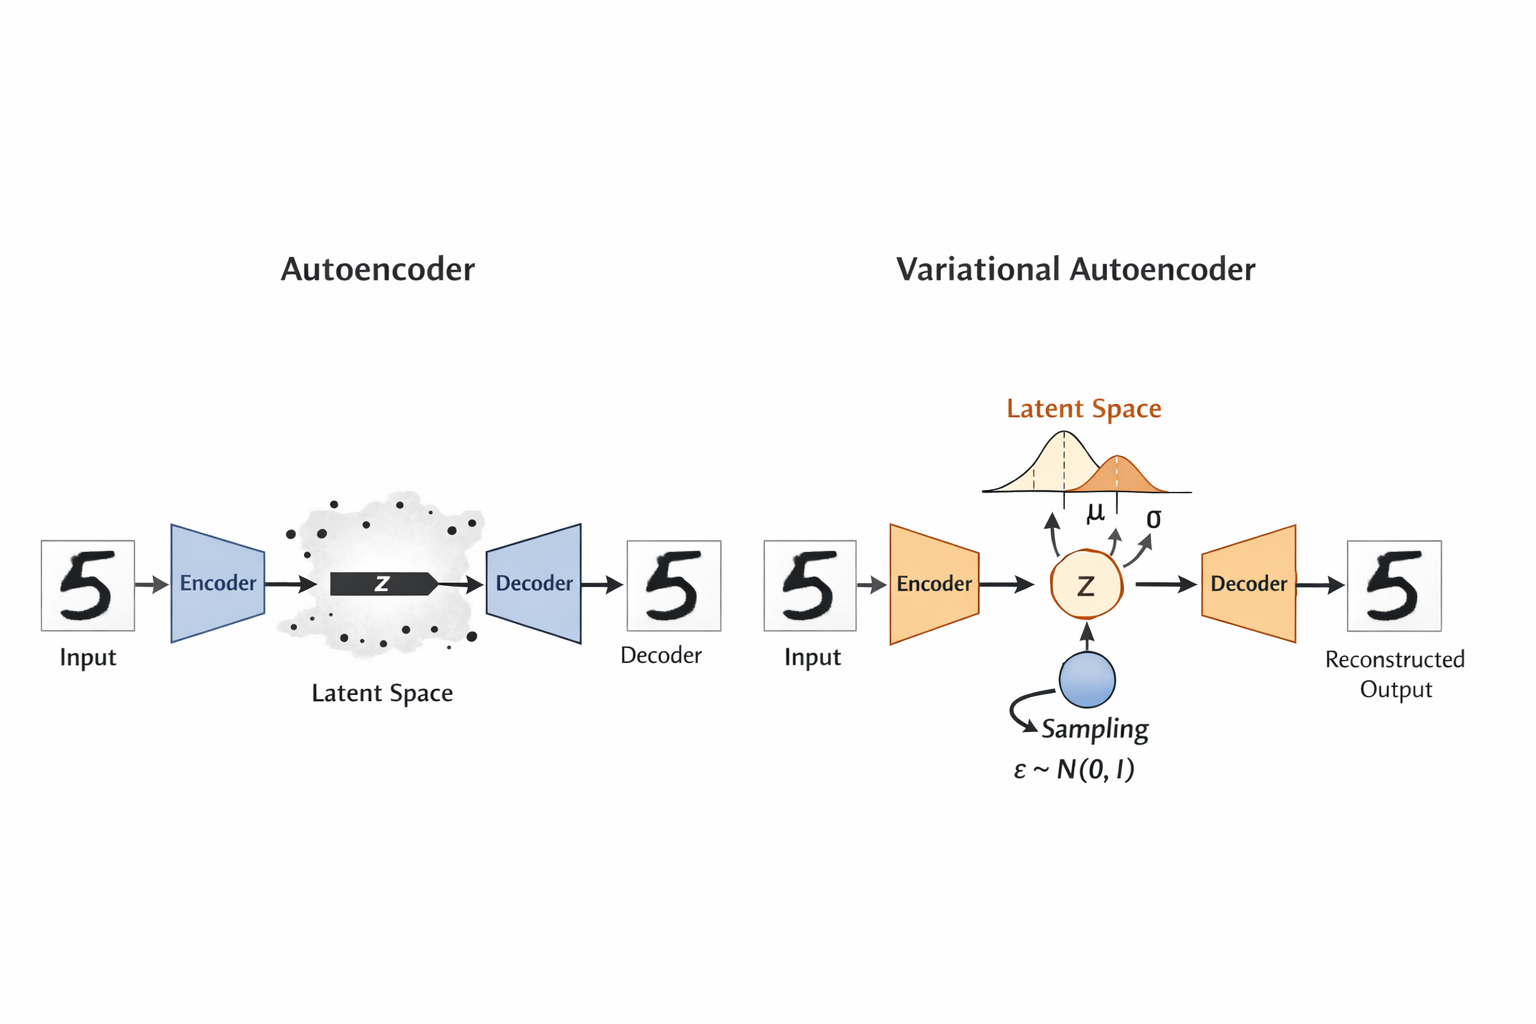


## 2.2 Why go beyond a deterministic Autoencoder?

A deterministic AE learns:
$$
x \xrightarrow{\text{enc}} z \xrightarrow{\text{dec}} \hat{x}
$$

Great for compression/reconstruction, but not a principled generator:
- no explicit model for $p_\theta(x)$
- latent space can be irregular ("holes")
- sampling random $z$ (e.g., from $\mathcal{N}(0,I)$) often decodes to nonsense

A VAE makes $z$ **probabilistic** and **regularized**, so sampling is meaningful.

A deterministic autoencoder (AE) learns a *single* code for each input:

$$
x \xrightarrow{\text{encoder } f_\phi} z \xrightarrow{\text{decoder } g_\theta} \hat{x}
$$

and typically trains with a reconstruction objective such as:

$$
\min_{\phi,\theta}\ \mathbb{E}_{x\sim p_{\text{data}}}\Big[\|x - g_\theta(f_\phi(x))\|^2\Big].
$$

This makes AEs excellent for **compression** and **reconstruction**, but not a principled **generative** model.  
Here’s the core reason: **an AE does not define a probability model of the data**.


### An AE does not define a likelihood or density

A generative model should define something like:

$$
p_\theta(x)
\quad\text{or}\quad
p_\theta(x|z)\ \text{with a prior}\ p(z).
$$

A deterministic AE only defines a mapping $x\mapsto \hat{x}$; it does **not** tell you:
- how likely an $x$ is (no $\log p_\theta(x)$),
- what distribution latent codes should follow (no meaningful $p(z)$),
- how to sample new realistic points in a principled way.

So the AE objective is **reconstruction**, not **density modeling**.


### The latent space is unconstrained → “holes” / disconnected regions

The encoder is free to place data codes anywhere in latent space, as long as decoding reconstructs well.  
So the set of codes:

$$
\{z_i = f_\phi(x_i)\}
$$

can form clusters/manifolds with **empty regions ("holes")** between them.

Nothing forces:
- nearby $z$ values to decode to valid data,
- or random $z$ values to land on the “data manifold.”


### Sampling is ill-defined (and usually fails)

A tempting generative workflow is:

$$
z \sim \mathcal{N}(0,I),\quad \tilde{x} = g_\theta(z).
$$

But the AE was never trained so that $z$ looks like $\mathcal{N}(0,I)$ (or any known distribution).  
So sampling from a standard Gaussian often lands in the “holes” → decoding produces nonsense.

- AE: “put training points somewhere in latent space $z$ and reconstruct them.”
- VAE: “put them somewhere **near a known distribution** of $z$ so that random samples land in valid regions.”



## 2.3 VAE **basic idea**

### Prior on latent variables
We choose a simple prior:
$$
p(z) = \mathcal{N}(0, I)
$$

### Decoder = generative model
The decoder defines a likelihood where we need to estimate $\theta$:
$$
p_\theta(x|z)
$$
- For images in $[0,1]$, a common choice is Bernoulli per pixel (BCE loss).
- For real-valued vectors, a common choice is Gaussian (MSE loss corresponds to fixed-variance Gaussian).

### Encoder = variational posterior
We approximate the intractable true posterior $p_\theta(z|x)$ with:
$$
q_\phi(z|x) = \mathcal{N}\!\big(\mu_\phi(x), \mathrm{diag}(\sigma^2_\phi(x))\big)
$$
where the encoder network outputs **$\mu_\phi(x)$ and $\log \sigma^2_\phi(x)$**.


## 2.4 Maximizing Data Likelihood


When the model is trained, we will give the decoder sampled $z$ as input and it will generate $x$ (e.g., an image) using the decoder. 

We assume:

1. Sample a latent variable:
$$
z \sim p(z)
$$

2. Generate data from a conditional model (decoder):
$$
x \sim p_{\theta}(x\mid z)
$$

Then the probability of observing $x$ (marginalizing out unknown causes $z$) is:

$$
p_\theta(x) = \int p_\theta(x,z)\,dz
= \int p_\theta(x|z)\,p(z)\,dz.
$$

This is just marginal probability: **sum/integrate over all hidden explanations**. 

In VAEs, we usually choose:

- A simple prior:
$$
p(z) = \mathcal{N}(0, I)
$$

- A neural decoder (highly nonlinear):
$$
p_{\theta}(x\mid z) \;\text{parameterized by a neural network}
$$

Then:

- The integral is over a **high-dimensional** continuous space (often $z\in\mathbb{R}^{16}\text{ to }\mathbb{R}^{256}$).
- The decoder is nonlinear, so there is **no closed form** for
$$
\int p_{\theta}(x\mid z)p(z)dz.
$$
- Naive Monte Carlo estimates can have **high variance**, making gradients noisy.

Next, we show this problem clearly in **1D**, where the integral is actually computable and we can compare “truth” vs approximations.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# just the definitions of the normal pdf and logsumexp functions, which are used in the EM algorithm
def normal_pdf(x, mu, sigma):
    return (1.0/(math.sqrt(2*math.pi)*sigma)) * np.exp(-0.5*((x-mu)/sigma)**2)

# the logsumexp function is used to compute the log of the sum of exponentials in a numerically stable way
# where a is a vector of log probabilities, and we want to compute log(sum(exp(a)))
# a correspond to ptheta in the algorithm, which are the log probabilities of the data given the current parameters of the

def logsumexp(a):
    a = np.asarray(a)
    m = np.max(a)
    return m + np.log(np.sum(np.exp(a-m)))

## 2.5 1D Simple Latent-Variable Model

We define:

- Prior:
$$
z \sim \mathcal{N}(0, 1)
$$

- Decoder:
$$
x \mid z \sim \mathcal{N}(f(z), \sigma_x^2)
$$

with a nonlinear mean function (like a tiny “neural decoder”). In reality, this will be a neural network:
$$
f(z) = z^3
$$

Even in 1D, this makes the marginal:

$$
p(x) = \int \mathcal{N}(x; f(z), \sigma_x^2)\, \mathcal{N}(z;0,1)\,dz
$$

nontrivial, but we *can* compute it numerically with a dense grid. That gives us “ground truth” for comparison.

In [ ]:
# Small model parameters for the nonlinear decoder example
sigma_x = 0.35

# this is the nonlinear decoder function, which maps the latent variable z to the mean of the observed variable x
def f(z):
    return z**3  # nonlinear decoder mean

# Choose an arbitrary x value we want to evaluate log p(x) for
x0 = 0.7

# "True" log p(x0) via numerical integration on a dense grid over z
z_grid = np.linspace(-6, 6, 20001)

# pz is the prior distribution over z, which is a standard normal distribution in this case
pz = normal_pdf(z_grid, 0.0, 1.0)

# px_given_z is the likelihood of observing x0 given z, which is a normal distribution with mean f(z) and standard deviation sigma_x
px_given_z = normal_pdf(x0, f(z_grid), sigma_x)

# We compute p(x) by integrating over z: p(x) = ∫ p(x|z) p(z) dz
px = np.trapz(px_given_z * pz, z_grid)
# print px
print("True p(x0) =", px)
# To avoid numerical issues with log(0), we add a small constant to px before taking the log
log_px_true = np.log(px + 1e-300)

print("True log p(x0):", log_px_true)

### Why Do We Choose a Specific x0?

We are trying to compute the marginal likelihood:

$
p(x) = \int p(x \mid z)\, p(z)\, dz.
$

This quantity is a function of x.

To evaluate it numerically, we must plug in a specific value of x.

So we choose:

$
x_0 = 0.7.
$

This simply asks:

What is the probability of observing the value 0.7 under this model?

### What the Code Is Doing

We define:

Prior:
$
p(z) = \mathcal{N}(0,1)
$

Likelihood:
$
p(x \mid z) = \mathcal{N}(f(z), \sigma_x^2)
$

with nonlinear decoder:

$
f(z) = z^3.
$

We then compute:

$
p(x_0) = \int p(x_0 \mid z)\, p(z)\, dz.
$

This is approximated numerically using a dense grid over z.

### Why We Must Fix $x_0$

The integral depends on x.

Without choosing a specific value:

- We cannot evaluate the integral.
- We cannot compute log p(x).
- We cannot compare it to the ELBO.

So we fix x0 to make the computation concrete.

### Connection to VAE Training

In real VAE training:

- We compute the ELBO for each data point.
- Then average over the dataset.

Here, we isolate a single data point to:

- Compute the true log p(x0)
- Compare it with the ELBO approximation
- Visualize the posterior
- Study the ELBO gap

#### Summary

The model defines a probability distribution over all x.

Choosing x0 asks:

How likely is this specific observation?

The marginal likelihood is defined pointwise.

So to compute it, we must choose a point.

We pick x0 because:

The marginal likelihood p(x) is defined for a specific value of x,
and numerical integration requires a concrete input.


### Computing Full Marginal Distribution

A program can compute the **full marginal distribution**:

$
p(x) = \int p(x \mid z)\, p(z)\, dz
$

for many values of x.

#### Step 1: Define the Generative Model

We assume:

Prior:
$
p(z) = \mathcal{N}(0,1)
$

Likelihood:
$
p(x \mid z) = \mathcal{N}(f(z), \sigma_x^2)
$

with nonlinear decoder:

$
f(z) = z^3.
$

#### Step 2: Fix a Grid Over x

Instead of computing the integral for a single value $x_0$, we evaluate it for many values of x:

$
x \in \text{grid}.
$

#### Step 3: Numerical Integration

For each value of x, we compute:

$
p(x) = \int p(x \mid z)\, p(z)\, dz
$

using numerical integration over a dense grid in z.

#### Step 4: Plot the Result

The program plots the resulting density curve.

This shows the **true marginal distribution of x**
implied by the latent-variable generative model.

#### Summary

The program reconstructs the full data distribution by integrating out the latent variable.


In [ ]:
# Define grid over x
x_grid = np.linspace(-4, 4, 1000)

px_full = []

for x_val in x_grid:
    px_given_z = normal_pdf(x_val, f(z_grid), sigma_x)
    px = np.trapz(px_given_z * pz, z_grid)
    px_full.append(px)

px_full = np.array(px_full)

# Normalize (optional numerical cleanup)
px_full /= np.trapz(px_full, x_grid)

plt.figure(figsize=(6,4))
plt.plot(x_grid, px_full)
plt.title("Full marginal distribution p(x)")
plt.xlabel("x")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.show()


### Visualizing the integrand

The integrand is:
$$
p(x\mid z)\,p(z)
$$

Often has **peaks** because only a narrow range of $z$ contributes meaningfully to the integral for a given $x$.
This is part of why naive sampling can be inefficient.

In [ ]:
integrand = px_given_z * pz

plt.figure(figsize=(7,4))
plt.plot(z_grid, integrand)
plt.title("Integrand: p(x0|z) p(z) (1D)")
plt.xlabel("z")
plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.show()

print("True log p(x0) =", log_px_true)

## 2.6 Monte Carlo estimate of $\log p(x)$ (and why it can be noisy)

A naive Monte Carlo estimator for $p(x)$ is:

$$
p(x) \approx \frac{1}{K} \sum_{k=1}^K p(x\mid z_k),
\quad z_k\sim p(z)
$$

Then:

$$
\log p(x) \approx \log \left(\frac{1}{K} \sum_{k=1}^K p(x\mid z_k)\right)
$$

Two practical issues:

1. **Most prior samples** $z_k\sim p(z)$ may land in regions where $p(x\mid z_k)$ is tiny.
2. Taking a **log of an average** can produce high variance estimates (especially for small $K$).

Below we compare estimates for different $K$.

In [ ]:
# Monte Carlo estimation of log p(x0) for different values of K (number of samples)
# this function estimates log p(x) using Monte Carlo sampling by drawing K samples of z from the prior distribution 
# and computing the average likelihood of x given those samples

def mc_log_px(x, K, trials=2000):
    est = []
    for _ in range(trials):
        z = np.random.randn(K)  # z ~ N(0,1)
        px_given = normal_pdf(x, f(z), sigma_x)
        # just calculating the average likelihood of x given the K samples of z, which is an estimate of p(x)
        px_hat = np.mean(px_given)
        est.append(np.log(px_hat + 1e-300))
    return np.array(est)

# calculate the Monte Carlo estimates of log p(x0) for different values of K and plot the results
Ks = [1, 5, 20, 100, 500]
ests = {K: mc_log_px(x0, K, trials=2000) for K in Ks}

plt.figure(figsize=(10,5))
for i, K in enumerate(Ks):
    plt.subplot(1, len(Ks), i+1)
    plt.hist(ests[K], bins=30)
    plt.axvline(log_px_true, linestyle="--")
    plt.title(f"K={K}")
    plt.xticks([])
plt.suptitle("Monte Carlo estimates of log p(x0): dashed line = true log p(x0)")
plt.tight_layout()
plt.show()

for K in Ks:
    m = ests[K].mean()
    s = ests[K].std()
    print(f"K={K:>3d}  mean={m:.3f}  std={s:.3f}  bias={m-log_px_true:.3f}")

### This simple example shows that 

- For small $K$, the estimate of $\log p(x)$ is **very noisy** or has **high variance**.
- The distribution can be skewed, because many samples yield extremely small $p(x\mid z)$.
- Larger $K$ reduces variance but becomes expensive in high dimensions.

In a real VAE:
- $z$ can have dozens or hundreds of dimensions.
- A neural decoder makes each evaluation $p_\theta(x\mid z)$ costly.
- Therefore, estimating $\log p_\theta(x)$ directly is usually impractical during training.

So rather than maximizing $\log p_\theta(x)$, we optimize a **lower bound** that is differentiable and efficient.


## 2.7 The Evidence Lower Bound (ELBO): a tractable lower bound

Since $\log p_\theta(x)$ is generally not tractable, we optimize a **lower bound** that is differentiable and efficient. The idea is that if we maximize the **lower bound**, in some sense we are maximizing $\log p_\theta(x)$.

### Our goal: the marginal likelihood (marginal probability)

We want to maximize the **marginal probability** of data:

$$
p_\theta(x) = \int p_\theta(x|z)\,p(z)\,dz.
$$

Taking logs (for MLE):

$$
\log p_\theta(x) = \log\int p_\theta(x|z)\,p(z)\,dz.
$$

The difficulty is the log of an integral.

### We Introduce a distribution we can sample from: $q_\phi(z|x)$

Pick any distribution $q_\phi(z|x)$ that is nonzero wherever $p(z)p_\theta(x|z)$ is nonzero.

Multiply and divide inside the integral:

$$
\log p_\theta(x)
= \log \int q_\phi(z|x)\ \frac{p_\theta(x|z)\,p(z)}{q_\phi(z|x)}\ dz.
$$

Now recognize the integral as an expectation under $q_\phi(z|x)$:

$$
\log p_\theta(x)
= \log\ \mathbb{E}_{z\sim q_\phi(z|x)}
\left[
\frac{p_\theta(x|z)\,p(z)}{q_\phi(z|x)}
\right].
$$

Define the positive random variable:

$$
Y(z) \;=\; \frac{p_\theta(x|z)\,p(z)}{q_\phi(z|x)}.
$$

Notice: $Y(z) > 0$ (it is a ratio of densities).

So we can apply Jensen to $\log$.

### Remember Jensen’s Inequality 

Let $f$ be a **concave** function and let $Y$ be a random variable.  
Then Jensen’s inequality says:

$$
f\big(\mathbb{E}[Y]\big)\ \ge\ \mathbb{E}\big[f(Y)\big].
$$

Equivalently, for a **convex** function $g$, we have:

$$
g\big(\mathbb{E}[Y]\big)\ \le\ \mathbb{E}\big[g(Y)\big].
$$

A crucial fact we will use:

- The function $\log(\cdot)$ is **concave** on $(0,\infty)$.

So Jensen gives:

$$
\log\big(\mathbb{E}[Y]\big)\ \ge\ \mathbb{E}[\log Y]
\quad\text{(as long as } Y>0\text{)}.
$$


### Apply Jensen explicitly 

Since $\log$ is concave:

$$
\log\ \mathbb{E}_{q_\phi}[Y(z)]
\ \ge\
\mathbb{E}_{q_\phi}\big[\log Y(z)\big].
$$

Substitute our $Y(z)$:

$$
\log p_\theta(x)
=
\log\ \mathbb{E}_{q_\phi(z|x)}
\left[
\frac{p_\theta(x|z)\,p(z)}{q_\phi(z|x)}
\right]
\ \ge\
\mathbb{E}_{q_\phi(z|x)}
\left[
\log
\frac{p_\theta(x|z)\,p(z)}{q_\phi(z|x)}
\right].
$$

This right-hand side is the **Evidence Lower Bound** (ELBO).


### Expand the log fraction

Use $\log\frac{a}{b}=\log a-\log b$:

$$
\mathbb{E}_{q_\phi(z|x)}
\left[
\log p_\theta(x|z) + \log p(z) - \log q_\phi(z|x)
\right].
$$

Now regroup:

$$
\mathcal{L}_{\text{ELBO}}(x)
=
\underbrace{
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
}_{\text{reconstruction / likelihood}}
\;-\;
\underbrace{
\mathbb{E}_{q_\phi(z|x)}
\left[
\log\frac{q_\phi(z|x)}{p(z)}
\right]
}_{\mathrm{KL}(q_\phi(z|x)\|p(z))}.
$$

So we get the standard ELBO:

$$
\mathcal{L}_{\text{ELBO}}(x)
=
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
\mathrm{KL}(q_\phi(z|x)\|p(z)).
$$

### Why is it called a *lower bound*?

Because we proved:

$$
\log p_\theta(x)\ \ge\ \mathcal{L}_{\text{ELBO}}(x).
$$

So $\mathcal{L}_{\text{ELBO}}(x)$ is always **below** the true log-likelihood.


### When is the bound tight?

We can show:

$$
\log p_\theta(x) - \mathcal{L}_{\text{ELBO}}(x)
=
\mathrm{KL}(q_\phi(z|x)\|p_\theta(z|x)) \ge 0.
$$

So the bound becomes **exact** when:

$$
q_\phi(z|x)=p_\theta(z|x).
$$

That is: when the encoder matches the true posterior.

### Summary

We replaced “log of an average” with “average of a log”:

- **Hard**: $\log \mathbb{E}[\cdot]$
- **Easier**: $\mathbb{E}[\log(\cdot)]$

and Jensen guarantees the second is a **lower bound** on the first.




### Understanding the Expectation term

$
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
$

#### What Does This Expression Mean?

This term appears in the ELBO.

It means:

Take an average of the log-likelihood of the data, where the averaging is done over the approximate posterior
$
q_\phi(z \mid x).
$

In words:

> "How well does the decoder reconstruct x, averaged over plausible latent values z?"

#### A Simple Concrete Example

Suppose:

Prior:
$
z \sim \mathcal{N}(0,1)
$

Decoder:
$
p(x \mid z) = \mathcal{N}(z, 0.5^2)
$

So the decoder mean is:
$
f(z) = z.
$

Now suppose we observe:

$
x = 1.0.
$

Assume our approximate posterior is:

$
q_\phi(z \mid x) = \mathcal{N}(1.2, 0.3^2).
$

#### What the Expectation Does

We compute:

$
\mathbb{E}_{q(z|x)}[\log p(x|z)]
$

Step-by-step:

1. Sample several z values from
   $
   z \sim \mathcal{N}(1.2, 0.3^2)
   $

2. For each sampled z, compute:

   $
   \log p(x=1.0 \mid z)
   $

3. Average these log probabilities.

#### What Is log p(x|z)?

Since:

$
p(x \mid z) = \mathcal{N}(z, 0.5^2),
$

If

$
p(x \mid z) = \mathcal{N}(z, \sigma^2),
$

then the probability density of a Gaussian is:

$$
p(x \mid z)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(x - z)^2}{2\sigma^2}
\right).
$$

In our example:

$
\sigma^2 = 0.5^2.
$

Now take the logarithm:

$$
\log p(x \mid z)
=
\log \left(
\frac{1}{\sqrt{2\pi\sigma^2}}
\right)
-
\frac{(x - z)^2}{2\sigma^2}.
$$

The first term:

$$
\log \left(
\frac{1}{\sqrt{2\pi\sigma^2}}
\right)
$$

does not depend on x or z.

It is just a constant.

So we can write:

$$
\log p(x \mid z)
=
-\frac{(x - z)^2}{2\sigma^2}
+
\text{constant}.
$$

Substitute:

$
\sigma^2 = 0.5^2
$

and we get:

$$
\log p(x \mid z)
=
-\frac{(x - z)^2}{2(0.5^2)}
+
\text{constant}.
$$

So:

- If z is close to x,
  the log likelihood is large.
- If z is far from x,
  the log likelihood is small.

#### Intuition

The expectation measures:

> On average, how well does the decoder explain x, if z is drawn from the encoder’s belief distribution?

If:

- $q(z|x)$ is centered near good reconstruction values,
  this term is large.
- $q(z|x)$ puts mass in bad regions,
  this term decreases.

#### Why We Average

We cannot just evaluate at one z.

Because the encoder says:

$
z \sim q_\phi(z \mid x).
$

So instead of picking one latent code, we evaluate reconstruction quality across all plausible latent codes.


#### Summary

This term means:

> "Average reconstruction quality of x, under the encoder's distribution over latent variables."

It encourages:

- q(z|x) to place probability mass where reconstruction is good.
- The decoder to map those z values back to x accurately.


Next, we demonstrate the bound numerically in the same 1D simple example by choosing a simple Gaussian family for $q(z\mid x)$ and optimizing its parameters to maximize the ELBO for a fixed $x_0$.


## Integrand and the True Posterior

For a fixed $x_0$, the true posterior satisfies:

$$
p(z\mid x_0) \propto p(x_0\mid z)p(z).
$$

So the *shape* of the posterior is exactly the shape of the integrand. We can visualize both in 1D.


In [ ]:
# Unnormalized posterior: p(z|x0) ∝ p(x0|z) p(z) for x0 fixed, as a function of z
unnorm_post = px_given_z * pz

# Normalize it numerically to get the true posterior p(z|x0)
# trapz is a numerical integration method that approximates the integral of a function by summing the areas of 
# trapezoids under the curve defined by the function values at the grid points

Z = np.trapz(unnorm_post, z_grid)
p_true = unnorm_post / (Z + 1e-300)

# True marginal likelihood p(x0) and log p(x0)
px = Z
log_px_true = np.log(px + 1e-300)

log_px_true

plt.figure(figsize=(8,4))
plt.plot(z_grid, unnorm_post, label=r"$p(x_0\mid z)p(z)$ (unnormalized)")
plt.title("Integrand shape (unnormalized posterior)")
plt.xlabel("z"); plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(z_grid, p_true, label=r"$p(z\mid x_0)$ (normalized)")
plt.title("True posterior (normalized)")
plt.xlabel("z"); plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("True log p(x0) =", log_px_true)

### Proof that

$
p(z \mid x_0) \propto p(x_0 \mid z) p(z)
$

##### Start from Bayes' Rule

Bayes' theorem states:

$
p(z \mid x) = \frac{p(x \mid z) p(z)}{p(x)}.
$

This holds for any latent-variable model.

#### Expand the Denominator

The marginal likelihood is:

$
p(x) = \int p(x \mid z) p(z) \, dz.
$

So we can write:

$$
p(z \mid x) =
\frac{p(x \mid z) p(z)}
{\int p(x \mid z') p(z') \, dz'}.
$$

## Fix a Specific Observation

Now choose a specific data point:

$
x = x_0.
$

Then:

$$
p(z \mid x_0) =
\frac{p(x_0 \mid z) p(z)}
{\int p(x_0 \mid z') p(z') \, dz'}.
$$

## Recognize the Proportional Form

The denominator does not depend on $z$.

It is simply a normalizing constant.

Therefore:

$
p(z \mid x_0) \propto p(x_0 \mid z) p(z).
$

This means:

The posterior is proportional to:

- The likelihood
- Times the prior

## Summary

For a fixed observation $x_0$:

- Values of $z$ that make $x_0$ likely (high $p(x_0 \mid z)$)
- And are themselves likely under the prior (high $$p(z)$)

will have high posterior probability.

The denominator simply rescales the result so it integrates to 1.

Yes, the result follows directly from Bayes' rule.

The posterior density over $z$ given $x_0$ is proportional to:

$
p(x_0 \mid z) p(z),
$

with the proportionality constant equal to:

$
\frac{1}{p(x_0)}.
$


## 2.8 ELBO Estimator for a Gaussian Variational Family

We restrict our approximation to:

$$
q(z\mid x_0)=\mathcal{N}(\mu_q,\sigma_q^2).
$$

The ELBO can be written as:

$$
\mathrm{ELBO}(x_0)
=
\mathbb{E}_{q(z\mid x_0)}\bigl[\log p(x_0\mid z) + \log p(z) - \log q(z\mid x_0)\bigr].
$$

We estimate this expectation by Monte Carlo sampling from $q(z\mid x_0)$.


In [ ]:
# Estimate the ELBO for given values of mu_q and log_sigma_q by sampling from q(z|x0) and computing the relevant log probabilities
def elbo_estimate(mu_q, log_sigma_q, S=4096):
    sigma_q = np.exp(log_sigma_q)
    # sample z ~ q
    z = mu_q + sigma_q * np.random.randn(S)
    # log p(x0|z)
    log_px_given = np.log(normal_pdf(x0, f(z), sigma_x) + 1e-300)
    # log p(z)
    log_pz = np.log(normal_pdf(z, 0.0, 1.0) + 1e-300)
    # log q(z|x0)
    log_qz = np.log(normal_pdf(z, mu_q, sigma_q) + 1e-300)
    # ELBO = E_q[log p(x|z) + log p(z) - log q(z|x)]
    return np.mean(log_px_given + log_pz - log_qz)

### Optimize $\mu_q$ and $\sigma_q$ to Maximize the ELBO

To keep this minimal (no autodiff), we use **finite-difference gradient ascent**.

We track:
- the ELBO over optimization steps,
- the best parameters found.

In [ ]:
# these are the initial parameters of the variational distribution q(z|x0), which is a Gaussian with mean mu_q and standard deviation sigma_q
mu_q = 0.0
log_sigma_q = 0.0  # sigma=1

lr = 0.2
steps = 80

hist_elbo = []
hist_mu = []
hist_sig = []

# we perform gradient ascent on the ELBO by estimating the gradients with finite differences and updating mu_q and log_sigma_q accordingly
for t in range(steps):
    base = elbo_estimate(mu_q, log_sigma_q, S=4096)
    hist_elbo.append(base)
    hist_mu.append(mu_q)
    hist_sig.append(np.exp(log_sigma_q))

# estimate the gradients with finite differences by perturbing mu_q and log_sigma_q slightly and measuring the change in the ELBO
    eps = 1e-2
    d_mu = (elbo_estimate(mu_q + eps, log_sigma_q, S=4096) - base) / eps
    d_ls = (elbo_estimate(mu_q, log_sigma_q + eps, S=4096) - base) / eps

# update the parameters using the estimated gradients
    mu_q += lr * d_mu
    log_sigma_q += lr * d_ls

best_t = int(np.argmax(hist_elbo))
best_elbo = hist_elbo[best_t]
best_mu = hist_mu[best_t]
best_sigma = hist_sig[best_t]

print("True log p(x0) =", log_px_true)
print("Best ELBO      =", best_elbo)
print("Gap (true - ELBO) =", log_px_true - best_elbo)
print("Best mu_q =", best_mu, "Best sigma_q =", best_sigma)

### Visual: ELBO Trajectory vs. True $\log p(x_0)$

The ELBO is a **lower bound**, so it should remain below the true $$\log p(x_0)$$. The distance to the dashed line is the **ELBO gap**.


In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_elbo, label="ELBO estimate")
plt.axhline(log_px_true, linestyle="--", label=r"true $\log p(x_0)$")
plt.title("ELBO maximization (Gaussian variational family)")
plt.xlabel("step"); plt.ylabel("value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 2.9 True Posterior vs. Learned Gaussian $q(z\mid x_0)$

Now we overlay:

- True posterior $p(z\mid x_0)$ (from numerical normalization)
- Best Gaussian approximation $q(z\mid x_0)$ (from ELBO maximization)

If the true posterior is not Gaussian, then even the best Gaussian cannot match it perfectly.
That mismatch corresponds to:

$$
\log p(x_0) - \mathrm{ELBO}(x_0)
=
\mathrm{KL}(q(z\mid x_0)\|p(z\mid x_0))
\ge 0.
$$

In [ ]:
q_pdf = normal_pdf(z_grid, best_mu, best_sigma)

plt.figure(figsize=(9,4))
plt.plot(z_grid, p_true, label=r"true $p(z\mid x_0)$")
plt.plot(z_grid, q_pdf, label=r"best Gaussian $q(z\mid x_0)$")
plt.title("True posterior vs. variational Gaussian approximation")
plt.xlabel("z"); plt.ylabel("density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Summary

1. The true posterior is:
$$
p(z\mid x_0) \propto p(x_0\mid z)p(z).
$$

2. We replace it with a simpler family:
$$
q(z\mid x_0)=\mathcal{N}(\mu_q,\sigma_q^2).
$$

3. Maximizing the ELBO finds the best distribution *within that family*.

4. The remaining ELBO gap exists when the variational family is too simple:
$$
\log p(x_0) - \mathrm{ELBO}(x_0) = \mathrm{KL}(q(z\mid x_0)\|p(z\mid x_0)).
$$


## 2.10 Encoder and decoder math in one place

### Encoder (learned)
Encoder network parameters: **$\phi$**  
Outputs:
$$
\mu_\phi(x),\ \log\sigma_\phi^2(x)
$$
Defines:
$$
q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \mathrm{diag}(\sigma_\phi^2(x)))
$$

### Reparameterization
$$
\epsilon \sim \mathcal{N}(0,I),\quad z=\mu_\phi(x)+\sigma_\phi(x)\odot\epsilon
$$

### Decoder (learned)
Decoder network parameters: **$\theta$**  
Defines likelihood:
$$
p_\theta(x|z)
$$

Common cases:
- **Bernoulli decoder** (MNIST-like):
  $$
  p_\theta(x|z)=\prod_i \text{Bernoulli}\big(x_i;\ \hat{x}_i(z)\big)
  $$
  Training uses BCE.
- **Gaussian decoder** (real-valued):
  $$
  p_\theta(x|z)=\mathcal{N}(x;\ \mu_\theta(z),\sigma^2 I)
  $$
  Training corresponds to MSE if $\sigma^2$ fixed.


### What parameters are learned?

A VAE typically learns:

#### Learned parameters (via gradient descent)
- **Encoder parameters** $\phi$: weights/biases that map $x \mapsto (\mu_\phi(x),\log\sigma_\phi^2(x))$
- **Decoder parameters** $\theta$: weights/biases that map $z \mapsto$ parameters of $p_\theta(x|z)$ (e.g., $\hat{x}$)

#### Fixed design choices (not learned)
- Prior $p(z)=\mathcal{N}(0,I)$ (usually fixed)
- Choice of likelihood family (Bernoulli vs Gaussian, etc.)
- Latent dimension $d_z$


### Why Does the Sign of the KL Term Change?

You may sometimes see:

$$
\text{ELBO} = \text{Reconstruction} - \mathrm{KL}
$$

and other times:

$$
\text{Loss} = \text{Reconstruction loss} + \mathrm{KL}
$$

These are **not contradictory**.

### Theoretical Objective (Maximize)

The VAE is derived by **maximizing the ELBO**:

$$
\text{ELBO}
=
\mathbb{E}_{q(z|x)}[\log p(x|z)]
-
\mathrm{KL}(q(z|x)\,\|\,p(z)).
$$

Here, KL is subtracted because we are maximizing.

### Practical Training (Minimize)

In neural network training, we usually **minimize a loss**.

So we define:

$
\text{Loss} = -\text{ELBO}.
$

Expanding:

$$
\text{Loss}
=
-\mathbb{E}[\log p(x|z)]
+
\mathrm{KL}.
$$

Since:

$
-\log p(x|z)
$

is the reconstruction loss (MSE or BCE), the loss becomes:

$
\text{Loss} = \text{Reconstruction loss} + \mathrm{KL}.
$

### Final Rule

- If you are **maximizing ELBO**, KL is subtracted.
- If you are **minimizing loss**, KL is added.

They represent the same objective written from opposite optimization perspectives.


## 2.11 The reparameterization trick — theory, motivation, and why it works

### The core problem: gradients through randomness

In a VAE, the encoder defines a **distribution**, not a single point and therefore we cannot back-propagate through it directly:

$$
q_\phi(z|x) = \mathcal{N}\big(\mu_\phi(x), \sigma_\phi^2(x)\big).
$$

The ELBO contains an expectation over this distribution:

$$
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)].
$$

To optimize the ELBO with gradient descent, we need gradients with respect to the **encoder parameters** $\phi$.

But naively sampling creates a problem:

- Sampling $z \sim q_\phi(z|x)$ looks like a *random operation*
- Gradients do **not** flow through random sampling in the usual sense

Formally, this is the difficulty:

$$
\nabla_\phi\ \mathbb{E}_{z\sim q_\phi(z|x)}[f(z)]
$$

is hard to estimate if $z$ is generated by a black-box sampling step.

### Why naive differentiation fails

If we write sampling explicitly:

$$
z \sim \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x)),
$$

then $z$ appears to be “drawn by chance,” and it is unclear how changing $\phi$ slightly should change a particular sample.

Without care:
- gradients have **high variance**
- training becomes unstable or very slow.

The reparameterization trick solves exactly this problem.


### Key idea: separate *noise* from *parameters*

Any Gaussian random variable can be rewritten as a **deterministic transformation** of a fixed noise source:

$$
\epsilon \sim \mathcal{N}(0,I), \qquad
z = \mu + \sigma \odot \epsilon.
$$

Here:
- $\epsilon$ carries **all the randomness**
- $\mu$ and $\sigma$ are now part of a **deterministic computation graph**

This turns sampling into a standard differentiable operation.


### What changes mathematically?

Instead of sampling:

$$
z \sim q_\phi(z|x),
$$

we sample:

$$
\epsilon \sim \mathcal{N}(0,I),
$$

and define:

$$
z = g_\phi(x,\epsilon) = \mu_\phi(x) + \sigma_\phi(x)\odot\epsilon.
$$

Now the expectation becomes:

$$
\mathbb{E}_{q_\phi(z|x)}[f(z)]
=
\mathbb{E}_{\epsilon\sim\mathcal{N}(0,I)}[f(g_\phi(x,\epsilon))].
$$

Crucially:
- the distribution of $\epsilon$ does **not** depend on $\phi$,
- all dependence on $\phi$ is inside a deterministic function.

### Why gradients now work

We can now move the gradient inside the expectation:

$$
\nabla_\phi
\mathbb{E}_{\epsilon}[f(g_\phi(x,\epsilon))]
=
\mathbb{E}_{\epsilon}
\big[
\nabla_\phi f(g_\phi(x,\epsilon))
\big].
$$

This is exactly what backpropagation computes.

In practice:
- we draw one (or a few) samples of $\epsilon$ per data point,
- compute $z$ deterministically,
- backpropagate through $\mu_\phi(x)$ and $\sigma_\phi(x)$.

This yields **low-variance**, stable gradient estimates.

### Why this estimator is better than alternatives

Without reparameterization, one would need score-function estimators such as:

$$
\nabla_\phi \mathbb{E}_{q_\phi(z|x)}[f(z)]
=
\mathbb{E}_{q_\phi}
\big[
f(z)\nabla_\phi \log q_\phi(z|x)
\big],
$$

which:
- have high variance,
- require variance-reduction tricks,
- train much more slowly in practice.

The reparameterization trick avoids this by exploiting the structure of continuous distributions.

### Why Gaussians are special and widely used

The trick works whenever we can write:

$$
z = g_\phi(\epsilon)
$$

for some fixed noise distribution $p(\epsilon)$.

Gaussians are ideal because:
- they admit a simple affine transformation,
- the KL divergence to $\mathcal{N}(0,I)$ has a closed form,
- gradients are stable and well-scaled.

This is one major reason **Gaussian latents dominate VAEs**.

### How this fits into the ELBO optimization

Recall the ELBO:

$$
\mathcal{L}_{\mathrm{ELBO}}(x)
=
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
\mathrm{KL}(q_\phi(z|x)\|p(z)).
$$

- The **KL term** can be computed analytically for Gaussians.
- The **expectation term** is estimated via reparameterized samples.

Together, this allows **end-to-end gradient-based optimization** of both:
- encoder parameters $\phi$,
- decoder parameters $\theta$.

### Summary

The reparameterization trick turns:

> “sampling from a parameterized distribution”

into:

> “passing fixed noise through a differentiable function,”

so that standard backpropagation can train a probabilistic latent-variable model.

### Why this should work

- It gives **unbiased, low-variance gradients**
- It scales naturally to deep neural networks
- It makes variational inference practical for high-dimensional data
- It is the key reason VAEs are trainable at all

Without the reparameterization trick, modern VAEs would simply not work in practice.


## Examples

Now we show some examples of how AE fails and VAE succeeds in learning the distribution.  We start with generating 1D dataset where we are trying ot learn a simple mixture of Gaussians. 

In [ ]:
# make some data sets for testing the VAE later on

def make_1d_mixture(n=4000):
    n1 = n//2
    n2 = n-n1
    x1 = np.random.randn(n1).astype(np.float32)*0.4 - 2.0
    x2 = np.random.randn(n2).astype(np.float32)*0.6 + 2.0
    x = np.concatenate([x1,x2]).astype(np.float32)
    y = np.concatenate([np.zeros(n1), np.ones(n2)]).astype(np.int64)
    idx = np.random.permutation(n)
    return x[idx], y[idx]

x1d, y1d = make_1d_mixture()

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax1.hist(x1d, bins=60)
ax1.set_title("1D mixture histogram")
plt.show()

## 2.12 Samping fails in AE 

When we reconstruct, we can get a good reconstruction. However, if we sample the $z$, the output is not correct. 

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------
# Assume x1d already exists (shape: [N])
# ------------------------------------------------

# DataLoader
dl1d = DataLoader(
    TensorDataset(torch.from_numpy(x1d).unsqueeze(1)),
    batch_size=256,
    shuffle=True
)

# ------------------------------------------------
# 1D Autoencoder
# ------------------------------------------------
class AE1D(nn.Module):
    def __init__(self, zdim=1, h=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(1, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            # zdim is the dimension of the latent code, which is 1 in this case
            nn.Linear(h, zdim)
        )
        self.dec = nn.Sequential(
            nn.Linear(zdim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, 1)
        )

    def encode(self, x):
        return self.enc(x)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        z = self.encode(x)
        xhat = self.decode(z)
        return xhat, z

# ------------------------------------------------
# Training loop
# ------------------------------------------------
def train_ae(model, loader, epochs=60, lr=1e-3):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []

    for _ in range(epochs):
        tot = 0.0
        n = 0
        for xb, in loader:
            xb = xb.to(device)
            xhat, _ = model(xb)
            # use the mean squared error loss to train the autoencoder to reconstruct the input xb from the latent code z
            loss = F.mse_loss(xhat, xb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot += loss.item() * xb.size(0)
            n += xb.size(0)

        hist.append(tot / n)

    return hist

# ------------------------------------------------
# Train AE
# ------------------------------------------------
ae1d = AE1D(zdim=1, h=64)
ae_hist1d = train_ae(ae1d, dl1d, epochs=60)

# ------------------------------------------------
# Plot training loss
# ------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(ae_hist1d, label="AE reconstruction loss")
plt.title("1D Autoencoder training loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

# ------------------------------------------------
# Reconstruction: x vs x_hat
# ------------------------------------------------
ae1d.eval()
with torch.no_grad():
    xb = torch.from_numpy(x1d).unsqueeze(1).to(device)
    xhat, z = ae1d(xb)
    xhat = xhat.cpu().numpy().ravel()
    z = z.cpu().numpy().ravel()

plt.figure(figsize=(8,4))
plt.scatter(x1d, xhat, s=2)
plt.plot(
    [x1d.min(), x1d.max()],
    [x1d.min(), x1d.max()],
    "r--",
    label="perfect reconstruction"
)
plt.title("Reconstruction: x vs x̂ (1D AE)")
plt.xlabel("x")
plt.ylabel("x̂")
plt.legend()
plt.show()

# ------------------------------------------------
# Latent code vs input
# ------------------------------------------------
plt.figure(figsize=(8,4))
plt.scatter(x1d, z, s=2)
plt.title("Latent mapping: z(x) vs x (1D AE)")
plt.xlabel("x")
plt.ylabel("z")
plt.show()

# ------------------------------------------------
# Sampling attempt (ill-defined for AE)
# ------------------------------------------------
with torch.no_grad():
    
    # since the AE does not have a well-defined latent space distribution, 
    # we can only sample z from a standard normal distribution and decode it to get "samples"
    #  in the data space, but these samples may not resemble the true data distribution

    z_rand = torch.randn(8000, 1).to(device)

    # ravel() is used to flatten the output of the decoder to a 1D array for plotting
    xs_ae = ae1d.decode(z_rand).cpu().numpy().ravel()

plt.figure(figsize=(8,4))
plt.hist(x1d, bins=80, alpha=0.6, label="data")
plt.hist(xs_ae, bins=80, alpha=0.6, label="AE samples (z ~ N(0,1))")
plt.title("1D: data vs AE 'samples'")
plt.legend()
plt.show()


## 2.13 VAE implementation (Gaussian latent)

In [ ]:
# this is the reparameterization trick, which allows us to sample from a Gaussian distribution with mean mu and log 
# variance logvar in a way that is differentiable with respect to mu and logvar

def sample_reparameterized(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

In [ ]:
class VAE(nn.Module):
    def __init__(self, xdim, zdim=2, h=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(xdim,h), nn.ReLU(), nn.Linear(h,h), nn.ReLU())
        # mean and log variance layers for the variational distribution q(z|x)
        self.mu = nn.Linear(h, zdim)
        self.logvar = nn.Linear(h, zdim)
        # decoder network that maps the latent code z back to the data space, which outputs the mean of the likelihood p(x|z)
        self.dec = nn.Sequential(nn.Linear(zdim,h), nn.ReLU(), nn.Linear(h,h), nn.ReLU(), nn.Linear(h, xdim))
        self.xdim = xdim
        self.zdim = zdim

    # encoder returns mean and log variance of the variational distribution q(z|x), which is a Gaussian in this case
    def encode(self,x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    # decoder takes a latent code z and outputs the mean of the likelihood p(x|z), which is a Gaussian in this case
    def decode(self,z):
        return self.dec(z)

    def forward(self,x):
        mu, logvar = self.encode(x)
        # we use the reparameterization trick to sample z from q(z|x) in a way that allows gradients to flow back through mu and logvar
        z = sample_reparameterized(mu, logvar)
        # we decode the sampled z to get the reconstruction xhat, which is the mean of the likelihood p(x|z)
        xhat = self.decode(z)
        return xhat, mu, logvar, z

def kl_normal(mu, logvar):
    return 0.5*torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

def train_vae(model, loader, epochs=60, lr=1e-3, beta=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist={"loss":[], "recon":[], "kl":[]}
    for _ in range(epochs):
        totL=totR=totK=0.0; n=0
        for xb, in loader:
            xb=xb.to(device)
            xhat, mu, logvar, _ = model(xb)
            # use mse loss for the reconstruction term and the KL divergence between q(z|x) and p(z) for the 
            # regularization term in the VAE loss function
            recon = F.mse_loss(xhat, xb, reduction="none").sum(dim=1)
            kl = kl_normal(mu, logvar)
            # loss is the sum of the reconstruction loss and the KL divergence, weighted by beta, 
            # which is a hyperparameter that controls the trade-off between reconstruction quality and latent space regularization
            loss = (recon + beta*kl).mean()
            opt.zero_grad(); loss.backward(); opt.step()

            # upated loss and metrics tracking to compute the average loss, reconstruction loss, and KL divergence over the entire epoch
            totL += loss.item()*xb.size(0)
            totR += recon.mean().item()*xb.size(0)
            totK += kl.mean().item()*xb.size(0)
            
            n += xb.size(0)
        hist["loss"].append(totL/n); hist["recon"].append(totR/n); hist["kl"].append(totK/n)
    return hist

### VAE Performs Better

Unlike AE, the VAE performs better at modelling the sampling distribution. 

In [ ]:
dl1d = DataLoader(TensorDataset(torch.from_numpy(x1d).unsqueeze(1)), batch_size=256, shuffle=True)
vae1d = VAE(xdim=1, zdim=1, h=64)
hist1d = train_vae(vae1d, dl1d, epochs=60, beta=1.0)

plt.figure(figsize=(8,4))
plt.plot(hist1d["loss"], label="total")
plt.plot(hist1d["recon"], label="recon")
plt.plot(hist1d["kl"], label="kl")
plt.title("1D VAE curves")
plt.xlabel("epoch"); plt.legend(); plt.show()

vae1d.eval()
with torch.no_grad():
    xb = torch.from_numpy(x1d).unsqueeze(1).to(device)
    mu, logvar = vae1d.encode(xb)
    mu = mu.cpu().numpy().ravel()

plt.figure(figsize=(8,4))
plt.scatter(x1d, mu, s=2)
plt.title("μ(x) vs x (1D VAE)")
plt.xlabel("x"); plt.ylabel("μ(x)")
plt.show()

with torch.no_grad():
    z = torch.randn(8000,1).to(device)
    xs = vae1d.decode(z).cpu().numpy().ravel()

plt.figure(figsize=(8,4))
plt.hist(x1d, bins=80, alpha=0.6, label="data")
plt.hist(xs, bins=80, alpha=0.6, label="samples")
plt.title("1D: data vs VAE samples")
plt.legend(); plt.show()

### Applying VAE to generate MNIST

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# ----------------------------
# 1) Data
# ----------------------------

import os
import torchvision
import torchvision.transforms as transforms

# Always use a writable local directory
DATA_ROOT = os.path.expanduser("./data")
os.makedirs(DATA_ROOT, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_ds = torchvision.datasets.MNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform
)

test_ds = torchvision.datasets.MNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_ds))
print("Test size :", len(test_ds))
print("Data stored in:", DATA_ROOT)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

# ----------------------------
# 2) VAE model
# ----------------------------
def sample_reparam(mu, logvar):
    # z = mu + sigma * eps, eps~N(0,I)
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

def kl_diag_gaussian(mu, logvar):
    # KL( N(mu, diag(sigma^2)) || N(0, I) )
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

class MNISTVAE(nn.Module):
    def __init__(self, zdim=16, h=400):
        super().__init__()
        self.zdim = zdim

        # Encoder: x -> (mu, logvar)
        self.enc = nn.Sequential(
            nn.Linear(28*28, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
        )
        self.mu = nn.Linear(h, zdim)
        self.logvar = nn.Linear(h, zdim)

        # Decoder: z -> xhat (Bernoulli params in [0,1])
        self.dec = nn.Sequential(
            nn.Linear(zdim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, 28*28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = sample_reparam(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar, z

# ----------------------------
# 3) Loss (ELBO) + training
# ----------------------------
def vae_elbo_loss(x, xhat, mu, logvar, beta=1.0):
    # Bernoulli likelihood -> BCE
    recon = F.binary_cross_entropy(xhat, x, reduction="none").sum(dim=1)  # per-sample
    kl = kl_diag_gaussian(mu, logvar)                                     # per-sample
    loss = (recon + beta * kl).mean()
    return loss, recon.mean().item(), kl.mean().item()

def train_vae(model, train_loader, epochs=10, lr=1e-3, beta=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"loss":[], "recon":[], "kl":[]}

    for ep in range(1, epochs+1):
        model.train()
        totL=totR=totK=0.0
        n=0
        for x, _ in train_loader:
            x = x.to(device).view(x.size(0), -1)  # flatten
            xhat, mu, logvar, _ = model(x)
            loss, r, k = vae_elbo_loss(x, xhat, mu, logvar, beta=beta)

            opt.zero_grad()
            loss.backward()
            opt.step()

            totL += loss.item() * x.size(0)
            totR += r * x.size(0)
            totK += k * x.size(0)
            n += x.size(0)

        hist["loss"].append(totL/n)
        hist["recon"].append(totR/n)
        hist["kl"].append(totK/n)

        print(f"epoch {ep:02d}/{epochs} | loss={hist['loss'][-1]:.1f} | recon={hist['recon'][-1]:.1f} | kl={hist['kl'][-1]:.2f}")

    return hist

@torch.no_grad()
def show_reconstructions(model, loader, n=10, title="Reconstructions"):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device).view(n, -1)
    xhat, _, _, _ = model(x)

    x = x.view(n, 28, 28).cpu().numpy()
    xhat = xhat.view(n, 28, 28).cpu().numpy()

    plt.figure(figsize=(10, 2.2))
    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        ax.imshow(x[i], cmap="gray")
        ax.axis("off")
        ax = plt.subplot(2, n, n+i+1)
        ax.imshow(xhat[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(title)
    plt.show()

@torch.no_grad()
def show_samples(model, n=20, title="Samples from prior"):
    model.eval()
    z = torch.randn(n, model.zdim).to(device)
    x = model.decode(z).view(n, 28, 28).cpu().numpy()

    cols = 10
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(10, 1.2*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(x[i], cmap="gray")
        ax.axis("off")
    plt.suptitle(title)
    plt.show()

# ----------------------------
# 4) Run training + plots
# ----------------------------
vae = MNISTVAE(zdim=16, h=400)
hist = train_vae(vae, train_loader, epochs=10, lr=1e-3, beta=1.0)

plt.figure(figsize=(9,4))
plt.plot(hist["loss"], label="total")
plt.plot(hist["recon"], label="recon")
plt.plot(hist["kl"], label="kl")
plt.title("MNIST VAE training curves")
plt.xlabel("epoch")
plt.legend()
plt.show()

show_reconstructions(vae, test_loader, n=10, title="MNIST VAE: input (top) vs recon (bottom)")
show_samples(vae, n=30, title="MNIST VAE: samples from z ~ N(0,I)")

# ----------------------------
# 5) Optional: 2D latent visualization (set zdim=2)
# ----------------------------
# If you want a 2D latent scatter, create vae = MNISTVAE(zdim=2, h=400) and retrain.
# Then run this cell section:
@torch.no_grad()
def plot_latent_2d(model, loader, max_batches=40, title="Latent means μ(x)"):
    model.eval()
    Z=[]
    Y=[]
    for bi, (x,y) in enumerate(loader):
        if bi >= max_batches:
            break
        x = x.to(device).view(x.size(0), -1)
        mu, _ = model.encode(x)
        Z.append(mu.cpu().numpy())
        Y.append(y.numpy())
    Z = np.concatenate(Z, axis=0)
    Y = np.concatenate(Y, axis=0)

    plt.figure(figsize=(6,6))
    plt.scatter(Z[:,0], Z[:,1], s=4, c=Y)
    plt.title(title)
    plt.xlabel("z1"); plt.ylabel("z2")
    plt.show()



In [ ]:
# What does the latent space look like when we set zdim=2 and retrain the VAE? 
plot_latent_2d(vae, test_loader, title="MNIST VAE (zdim=2): μ(x) colored by digit")

The VAE learned a smooth, Gaussian-aligned latent manifold for MNIST, but the representation is entangled and dominated by a single principal direction rather than clean independent factors.

## 2.14 Entanglement and Disentanglement in Latent Variable Models

### What do we mean by *entanglement*?

In a latent-variable model (such as a VAE), we say the representation is **entangled** when:

> **Each latent dimension mixes multiple underlying factors of variation in the data.**

Formally, let the true data-generating process depend on hidden factors (e.g., digit identity, stroke thickness, rotation, lighting):

$$
x = g(s_1, s_2, \dots, s_k),
$$

where $s_i$ are *independent* generative factors.

A latent representation $z = (z_1,\dots,z_d)$ is **entangled** if changing one $z_j$:
- affects multiple semantic properties of $x$, and
- cannot be interpreted independently of the other coordinates.

### What is *disentanglement*?

A representation is **disentangled** if:

> **Each latent dimension controls (approximately) one independent factor of variation.**

Ideally:
- $z_1$ ↔ digit identity  
- $z_2$ ↔ stroke width  
- $z_3$ ↔ rotation  
- $z_4$ ↔ slant  

Changing one coordinate while holding others fixed produces a **predictable, localized change** in the output.

### Why entanglement naturally occurs

Standard VAEs optimize the ELBO:

$$
\mathcal{L}
=
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
\mathrm{KL}(q_\phi(z|x)\|p(z)).
$$

Nothing in this objective explicitly enforces:
- independence between latent dimensions,
- semantic alignment with true factors.

As long as reconstruction is good and the aggregated posterior matches the prior, the model is free to:
- rotate latent space,
- mix factors across coordinates,
- encode information in correlated ways.

Hence, **entanglement is the default outcome**.

### Why entanglement is a problem

Entangled latents are:
- hard to interpret,
- fragile under downstream tasks,
- poor for controllable generation.

In practice, this means:
- interpolations change *many* attributes at once,
- manipulating one coordinate has unpredictable effects,
- conditioning or editing becomes difficult.

### Why disentanglement matters for VAEs

Disentangled representations enable:

1. **Controllable generation**  
   Modify a single factor (e.g., thickness) without altering identity.

2. **Robust interpolation**  
   Linear paths in latent space correspond to meaningful transitions.

3. **Transfer learning**  
   Latents align better with downstream predictors.

4. **Causal reasoning (approximate)**  
   Factors resemble independent causes rather than arbitrary codes.

### How VAEs attempt (and often fail) to disentangle

Standard VAEs:
- encourage *distributional* regularization (via the KL),
- but **do not** enforce *factorized semantics*.

Common strategies to promote disentanglement:
- **β-VAE**: increase pressure toward factorized priors  
- **FactorVAE / TC-VAE**: penalize total correlation  
- **Conditional VAEs**: separate known factors  
- **Structured priors**: mixture or hierarchical latents

All of these trade off **reconstruction fidelity** for **latent simplicity**.

### A fundamental limitation (important)

Perfect disentanglement **cannot be guaranteed without inductive bias or supervision**.

There exist infinitely many equally valid latent parameterizations that:
- reconstruct equally well,
- satisfy the prior,
- but differ by latent rotations.

Thus:
> Disentanglement is not something VAEs “discover”, it is something we **impose** through modeling choices.

### Summary
> **Entanglement is when latent variables act like a tangled knot and disentanglement is when each latent variable pulls on a single thread.**



## 2.15 Inductive Bias and why disentanglement does not come for free

### What is *inductive bias*?

An **inductive bias** is any assumption we build into a model that restricts the set of solutions it can learn.

More formally:

> **Inductive bias is the set of preferences a learning algorithm uses to choose one solution over many equally valid solutions that fit the data.**

Without inductive bias, learning is impossible: infinitely many models can explain the same observations.

### Where inductive bias appears in VAEs

A VAE already contains *some* inductive bias, for example:

- the assumption that latent variables are **Gaussian**
- the assumption that the prior factorizes:  
  $$
  p(z) = \prod_i p(z_i)
  $$
- the architectural bias of neural networks (continuity, smoothness)

However, **none of these biases specify semantic meaning**.

They constrain *distributional form*, not *interpretability*.

### Entanglement as a consequence of weak inductive bias

Recall the ELBO:

$$
\mathcal{L}
=
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
\mathrm{KL}(q_\phi(z|x)\|p(z)).
$$

This objective is **invariant under latent rotations**.

If $R$ is any orthogonal matrix, then:
- $z' = Rz$ has the same prior density,
- reconstruction quality is unchanged if the decoder adapts.

So the model has **no preference** for:
- axis-aligned factors,
- semantically meaningful coordinates,
- “one factor per dimension.”

**Entanglement is  expected**.

### Disentanglement requires *stronger* inductive bias

To encourage disentanglement, we must *break* this symmetry.

That means adding assumptions such as:

#### 1. Statistical bias
- Penalize correlations between latent dimensions  
  (e.g., Total Correlation penalties)

#### 2. Architectural bias
- Separate subnetworks per factor
- Hierarchical or grouped latents

#### 3. Objective bias
- β-VAE: overweight the KL term
- FactorVAE / TC-VAE: explicitly penalize dependence

#### 4. Supervision bias
- Conditional VAEs
- Partial labels or weak supervision

Each bias **restricts the solution space** so that:
> “simple, factorized explanations are preferred over complex, entangled ones.”

### The unavoidable trade-off

Adding inductive bias always trades one thing for another:

| More inductive bias | Less inductive bias |
|-------------------|-------------------|
| More interpretable | More flexible |
| Better disentanglement | Better reconstruction |
| Easier control | Higher fidelity |
| Strong assumptions | Fewer guarantees |

There is **no free lunch**.

### A key theoretical result (important to state explicitly)

> **Disentanglement is not identifiable from data alone.**

Without inductive bias or supervision:
- multiple latent representations explain the data equally well,
- no objective criterion can choose the “correct” one.

This is why disentanglement:
- cannot be guaranteed,
- must be *designed*, not discovered.

### Summary

> **Inductive bias is the reason a model chooses *this* explanation rather than a million others that also fit the data.**

For VAEs, disentanglement only emerges when we *force* the model to prefer simple, factorized latent explanations.

## 2.16 How β-VAE Addresses the Entanglement Problem 

### The core problem β-VAE is trying to fix

A standard VAE has **too much freedom** in how it uses the latent space.

As long as it:
- reconstructs the data well, and
- keeps the latent distribution roughly Gaussian,

it can **mix multiple factors together** inside each latent dimension.

This mixing is what we call **entanglement**.

### How β-VAE works

β-VAE modifies the VAE objective by **turning up the pressure to simplify the latent space**.

Instead of maximizing:

$$
\text{reconstruction} - \text{KL}
$$

it maximizes:

$$
\text{reconstruction} - \beta \times \text{KL}
$$

with **β > 1**.

### What does “increasing β” actually do?

Increasing β means:

> **“I care more about having a simple, factorized latent space than about perfect reconstruction.”**

Concretely, the model is punished more heavily when:
- latent variables carry too much information,
- different latent dimensions become correlated,
- the encoder deviates from an independent Gaussian prior.

This forces the model to:
- compress information more aggressively,
- drop redundant details,
- represent only the most important factors.

### Why this helps disentanglement

Under higher β:

- Each latent dimension becomes **information-limited**
- The model is encouraged to use each dimension **for one dominant factor**
- Mixing many factors into one variable becomes inefficient

So the easiest way for the model to perform well is to:
> “Assign one latent variable per major factor of variation.”

This does **not guarantee** perfect disentanglement, but it strongly **biases the model toward it**.

### The trade-off β-VAE makes (important)

β-VAE deliberately accepts:
- worse reconstructions,
- blurrier outputs,

in exchange for:
- cleaner latent structure,
- more interpretable dimensions,
- better control when generating samples.

This is not a flaw — it is the **design goal**.

### What β-VAE does *not* do

β-VAE:
- does **not** add supervision,
- does **not** identify “true” factors,
- does **not** magically discover semantics.

It only adds a **stronger inductive bias** toward simplicity and independence.

### When β-VAE works best

β-VAE is most effective when:
- the number of latent dimensions is close to the number of true factors,
- the data has clear, dominant modes of variation,
- perfect pixel-level reconstruction is not the main goal.

### One-sentence intuition

> **β-VAE disentangles by forcing the model to “explain less with more structure,” rather than “explain everything at once.”**

It trades accuracy for clarity — and that is exactly why it helps.


## 2.17 An example to demonstrate disentanglement using β-VAE

This example is designed to show how a **β-VAE encourages disentanglement** in a controlled 1D setting. Even though the observed data is 1-dimensional, we intentionally construct it to depend on **two independent underlying factors**:

$$
x = s \cdot a + \text{noise}
$$

where:

- $s \in \{-1, +1\}$ is a **discrete sign factor**
- $a \in [0.2, 2.0]$ is a **continuous amplitude factor**

So although we observe only a scalar $x$, it is generated from **two independent generative causes**.

The goal is to see whether the VAE can recover these two factors separately in its 2D latent space.

### Why Use a 2D Latent Space?

We set:

$
z \in \mathbb{R}^2
$

so the model has enough capacity to represent:

- One latent dimension encoding the sign factor $s$
- The other latent dimension encoding the amplitude factor $a$

If disentanglement occurs, we should observe:

- One axis correlated mainly with $s$
- The other axis correlated mainly with $a$

### What β Controls

The VAE objective is to minimize:

$
\mathcal{L} = \text{Reconstruction} + \beta \cdot \text{KL}
$

- When $\beta = 1$ → standard VAE.
- When $\beta > 1$ → stronger pressure to match the prior.

Increasing $\beta$:

- Penalizes latent capacity.
- Encourages independent latent dimensions.
- Often forces cleaner factor separation.

So we compare:

- $\beta = 1$(standard VAE)
- $\beta = 4$ (β-VAE)

### What Each Section of the Code Is Doing

#### Data generation

Creates synthetic data with known ground-truth factors:

- Sign factor $s$
- Amplitude factor $a$

This gives us supervision for evaluating disentanglement.

#### Training the VAE

Two models are trained:

- Standard VAE (β=1)
- β-VAE (β=4)

We record:

- Reconstruction loss
- KL divergence

This shows the tradeoff between:

- Reconstruction quality
- Latent regularization

#### Latent visualization

We compute the latent parameter $\mu(x)$ for every data point.

We then color the latent points by:

- Sign factor $s$
- Amplitude factor $a$

If disentanglement occurs:

- One latent axis separates positive vs negative sign.
- The other latent axis varies smoothly with amplitude.

#### Quantifying disentanglement

We compute correlations:

$
\text{corr}(z_1, s), \quad \text{corr}(z_2, s)
$

$
\text{corr}(z_1, a), \quad \text{corr}(z_2, a)
$

A clean separation would look like:

- One latent dimension strongly correlated with $s$
- The other strongly correlated with $a$
- Cross-correlations near zero

This is a simple but practical disentanglement metric.

#### Latent traversal (most important test)

We vary one latent dimension at a time:

- Fix $z_2 = 0$, vary $z_1$
- Fix $z_1 = 0$, vary $z_2$

Then decode.

If disentangled:

- Changing one axis modifies only one factor.
- The other axis modifies the other factor.

This is the clearest visual test of disentanglement.

### What This example shows

1. Disentanglement is about **factor separation**, not reconstruction accuracy.
2. Increasing $\beta$ reduces latent capacity.
3. Reduced capacity can encourage axis alignment with independent factors.
4. Too large $\beta$ may cause underfitting or posterior collapse.
5. Disentanglement emerges from inductive bias + regularization, not supervision.

### Summary

This exmaple shows that a β-VAE can encourage different latent dimensions to align with independent generative factors—even in a simple 1D setting—by increasing pressure from the KL regularization term.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------
# Repro + device
# ----------------------------
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1D data with TWO underlying factors (still 1D observed):
#   x = s * a + noise
# where:
#   s in {-1, +1}   (discrete "style/sign" factor)
#   a in [0.2, 2.0] (continuous "amplitude" factor)
# This lets us test whether z1 and z2 separate these factors.
# ----------------------------
def make_1d_two_factor(n=8000, noise_std=0.05):
    s = np.random.choice([-1.0, 1.0], size=n).astype(np.float32)
    a = np.random.uniform(0.2, 2.0, size=n).astype(np.float32)
    x = s * a + np.random.randn(n).astype(np.float32) * noise_std
    return x, s, a

x1d, s_factor, a_factor = make_1d_two_factor()
dl1d = DataLoader(
    TensorDataset(torch.from_numpy(x1d).unsqueeze(1)),
    batch_size=256,
    shuffle=True
)

# ----------------------------
# VAE Code
# ----------------------------
def sample_reparameterized(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

class VAE(nn.Module):
    def __init__(self, xdim, zdim=2, h=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(xdim,h), nn.ReLU(), nn.Linear(h,h), nn.ReLU())
        self.mu = nn.Linear(h, zdim)
        self.logvar = nn.Linear(h, zdim)
        self.dec = nn.Sequential(nn.Linear(zdim,h), nn.ReLU(), nn.Linear(h,h), nn.ReLU(), nn.Linear(h, xdim))
        self.xdim = xdim
        self.zdim = zdim

    def encode(self,x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def decode(self,z):
        return self.dec(z)

    def forward(self,x):
        mu, logvar = self.encode(x)
        z = sample_reparameterized(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar, z

def kl_normal(mu, logvar):
    return 0.5*torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

def train_vae(model, loader, epochs=60, lr=1e-3, beta=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist={"loss":[], "recon":[], "kl":[]}
    for _ in range(epochs):
        totL=totR=totK=0.0; n=0
        for xb, in loader:
            xb=xb.to(device)
            xhat, mu, logvar, _ = model(xb)
            recon = F.mse_loss(xhat, xb, reduction="none").sum(dim=1)
            kl = kl_normal(mu, logvar)
            loss = (recon + beta*kl).mean()
            opt.zero_grad(); loss.backward(); opt.step()

            totL += loss.item()*xb.size(0)
            totR += recon.mean().item()*xb.size(0)
            totK += kl.mean().item()*xb.size(0)
            n += xb.size(0)
        hist["loss"].append(totL/n); hist["recon"].append(totR/n); hist["kl"].append(totK/n)
    return hist

# ----------------------------
# Train: beta=1 vs beta=4 (β-VAE)
# ----------------------------
vae_b1 = VAE(xdim=1, zdim=2, h=64)
hist_b1 = train_vae(vae_b1, dl1d, epochs=80, beta=1.0)

vae_b4 = VAE(xdim=1, zdim=2, h=64)
hist_b4 = train_vae(vae_b4, dl1d, epochs=80, beta=4.0)

# Curves
plt.figure(figsize=(9,4))
plt.plot(hist_b1["recon"], label="recon β=1")
plt.plot(hist_b4["recon"], label="recon β=4")
plt.plot(hist_b1["kl"],   label="kl β=1")
plt.plot(hist_b4["kl"],   label="kl β=4")
plt.title("1D data, 2D latent: β-VAE effect")
plt.xlabel("epoch"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# ----------------------------
# Encode all points: look at μ(x)
# and color by underlying factors (sign s and amplitude a)
# ----------------------------
vae_b1.eval(); vae_b4.eval()
with torch.no_grad():
    xb = torch.from_numpy(x1d).unsqueeze(1).to(device)
    mu1, logvar1 = vae_b1.encode(xb)
    mu4, logvar4 = vae_b4.encode(xb)

mu1 = mu1.cpu().numpy()
mu4 = mu4.cpu().numpy()

# 1) Color by sign factor s (discrete)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(mu1[:,0], mu1[:,1], s=3, c=s_factor, cmap="coolwarm")
plt.title("β=1: μ(x) colored by sign s ∈ {−1,+1}")
plt.xlabel("z1"); plt.ylabel("z2"); plt.grid(True, alpha=0.2)

plt.subplot(1,2,2)
plt.scatter(mu4[:,0], mu4[:,1], s=3, c=s_factor, cmap="coolwarm")
plt.title("β=4: μ(x) colored by sign s ∈ {−1,+1}")
plt.xlabel("z1"); plt.ylabel("z2"); plt.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# 2) Color by amplitude factor a (continuous)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(mu1[:,0], mu1[:,1], s=3, c=a_factor, cmap="viridis")
plt.title("β=1: μ(x) colored by amplitude a")
plt.xlabel("z1"); plt.ylabel("z2"); plt.grid(True, alpha=0.2)

plt.subplot(1,2,2)
plt.scatter(mu4[:,0], mu4[:,1], s=3, c=a_factor, cmap="viridis")
plt.title("β=4: μ(x) colored by amplitude a")
plt.xlabel("z1"); plt.ylabel("z2"); plt.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# ----------------------------
# Quantify "disentanglement" (simple, practical proxy):
# correlation between each latent dimension and each factor
# (For a clean separation, one z aligns with s and the other with a.)
# ----------------------------
def corr(x, y):
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return float(np.mean(x*y))

def report_corr(mu, name):
    z1 = mu[:,0]
    z2 = mu[:,1]
    # For sign (discrete), correlation is meaningful because s is ±1
    c_z1_s = corr(z1, s_factor)
    c_z2_s = corr(z2, s_factor)
    c_z1_a = corr(z1, a_factor)
    c_z2_a = corr(z2, a_factor)
    print(f"\n[{name}] correlations (proxy disentanglement)")
    print(f"corr(z1, s) = {c_z1_s:+.3f}   corr(z2, s) = {c_z2_s:+.3f}")
    print(f"corr(z1, a) = {c_z1_a:+.3f}   corr(z2, a) = {c_z2_a:+.3f}")

report_corr(mu1, "β=1")
report_corr(mu4, "β=4")

# ----------------------------
# Latent traversal (most convincing visual):
# vary z1 while holding z2=0, and vice versa, and decode.
# If disentangled, each axis changes a "single factor" in x.
# Here x is 1D scalar, but you should see:
# - one axis tends to flip sign-like behavior,
# - the other axis tends to scale magnitude-like behavior,
# especially under β=4.
# ----------------------------
def traverse_and_decode(model, axis=0, vals=np.linspace(-3,3,61), fixed=0.0):
    model.eval()
    zs = np.zeros((len(vals), 2), dtype=np.float32)
    zs[:,0] = fixed
    zs[:,1] = fixed
    zs[:,axis] = vals.astype(np.float32)
    with torch.no_grad():
        xhat = model.decode(torch.from_numpy(zs).to(device)).cpu().numpy().ravel()
    return vals, xhat

vals, x_z1_b1 = traverse_and_decode(vae_b1, axis=0)
_,    x_z2_b1 = traverse_and_decode(vae_b1, axis=1)
_,    x_z1_b4 = traverse_and_decode(vae_b4, axis=0)
_,    x_z2_b4 = traverse_and_decode(vae_b4, axis=1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(vals, x_z1_b1, label="decode(z1 varies, z2=0)")
plt.plot(vals, x_z2_b1, label="decode(z2 varies, z1=0)")
plt.title("β=1 latent traversal")
plt.xlabel("latent value"); plt.ylabel("decoded x̂"); plt.grid(True, alpha=0.3); plt.legend()

plt.subplot(1,2,2)
plt.plot(vals, x_z1_b4, label="decode(z1 varies, z2=0)")
plt.plot(vals, x_z2_b4, label="decode(z2 varies, z1=0)")
plt.title("β=4 latent traversal (often more axis-separated)")
plt.xlabel("latent value"); plt.ylabel("decoded x̂"); plt.grid(True, alpha=0.3); plt.legend()

plt.tight_layout(); plt.show()


### Disentanglement Comparison: β = 1 vs β = 4

#### β = 1
- One latent axis carries most of the information.
- The other latent axis is nearly ignored.
- Information is concentrated in a single direction.
- Latent usage is unbalanced.
- This reflects an **entangled representation**, where factors are not cleanly separated.

#### β = 4
- Both latent axes contribute meaningfully.
- Variation is distributed more evenly across dimensions.
- Each axis affects the output in a more independent way.
- Latent structure appears more organized.
- This reflects **better axis separation** and improved disentanglement.

### Interpreting the Correlation Table: What Actually Happened

#### Reported Correlations

**β = 1**

- corr(z1, s) = +0.314  
- corr(z2, s) = +0.929  
- corr(z1, a) = +0.118  
- corr(z2, a) = +0.026  

**β = 4**

- corr(z1, s) = +0.911  
- corr(z2, s) = +0.879  
- corr(z1, a) = −0.068  
- corr(z2, a) = +0.068  

### What This Means

#### β = 1
- The sign factor **s** is strongly encoded in **z2**.
- The amplitude factor **a** is barely encoded.
- One latent dimension dominates; the other is weakly used.
This is **not clean disentanglement** — it is a case of *dominant-axis encoding*.

#### β = 4

- Both z1 and z2 are strongly correlated with **the same factor (s)**.
- Neither dimension meaningfully encodes amplitude.
- The model has duplicated the dominant factor across both axes.

This is **redundant encoding**, not disentanglement.

### Why This Is Important
Increasing β does **not automatically guarantee disentanglement**.

In this case:
- The stronger regularization pressure caused the model to
  compress information.
- It chose to encode only the dominant factor (sign).
- The weaker factor (amplitude) was largely ignored.

### What True Disentanglement Would Look Like

We would expect:
- One latent dimension strongly correlated with **s**
- The other strongly correlated with **a**
- Minimal cross-correlations

For example:

- corr(z1, s) ≈ 0.9  
- corr(z2, s) ≈ 0.0  
- corr(z1, a) ≈ 0.0  
- corr(z2, a) ≈ 0.9  

That clean axis separation is **not observed here**.

### Summary
> β-VAE increases pressure toward independence, but without balanced factors or additional constraints, the model may drop weaker factors or redundantly encode dominant ones instead of truly disentangling them.


## 2.18 How Conditional VAEs (CVAEs) Help with the Entanglement Problem

### The core idea

A **Conditional Variational Autoencoder (CVAE)** reduces entanglement by **telling the model some of the answers upfront**.

Instead of forcing the latent space to explain *everything* about the data, a CVAE says:

> “Here is a known factor (like a label). Don’t waste latent capacity rediscovering it but focus on what’s left.”

### Differences from a standard VAE

In a standard VAE:
- the latent variables must encode **all** sources of variation
- known and unknown factors get mixed together

In a CVAE:
- some factors (e.g. class, condition, context) are provided explicitly
- the latent variables only need to explain **residual variation**

This simple change dramatically reduces entanglement.

### What conditioning actually means

A CVAE models:

$$
p_\theta(x \mid z, c)
$$

and learns:

$$
q_\phi(z \mid x, c)
$$

where:
- $x$ = data (image, signal, etc.)
- $c$ = condition (label, attribute, metadata)
- $z$ = latent variables

The condition $c$ is fed into:
- the encoder, and
- the decoder.

So both sides **know the context**.

### Why this helps disentanglement

Without conditioning:
- the model must encode class, style, pose, etc. all into $z$
- these factors become entangled

With conditioning:
- class information lives in $c$
- $z$ is free to encode **style, variation, noise**

This creates a natural separation:

| Component | What it represents |
|---------|-------------------|
| Condition $c$ | Known, interpretable factors |
| Latent $z$ | Unknown or subtle variation |

Less competition inside $z$ → less entanglement.

### A concrete example (MNIST)

**Standard VAE**
- $z$ must encode digit identity *and* stroke thickness
- rotating or changing thickness can alter digit identity

**CVAE**
- digit label is given as $c$
- $z$ only controls style (thickness, slant, handwriting)
- changing $z$ preserves digit identity

This makes generation **controllable and predictable**.

### CVAE vs β-VAE

- **β-VAE** reduces entanglement by *restricting capacity*
- **CVAE** reduces entanglement by *removing known factors*

They solve the problem from **different directions** and are often complementary.

### What CVAEs do *not* solve

CVAEs:
- do not disentangle *unknown* factors automatically
- require labels or side information
- only disentangle what you explicitly condition on

They **shift**, rather than eliminate, the burden of representation.

### When CVAEs are the right tool

Use a CVAE when:
- you have reliable labels or metadata
- you want control over specific attributes
- interpretability matters more than full autonomy

### Summary

> **A CVAE disentangles by saying: “This part is known so don’t encode it again.”**

By removing known causes from the latent space, CVAEs make what remains **simpler, cleaner, and more interpretable**.

## 2.19 Conditional VAE (CVAE): why conditioning makes sense

Suppose each data point has a label or condition $y$ (class, attribute, text prompt, etc.).

### Goal
Instead of modeling $p(x)$, we want to model:
$
p(x|y)
$
So we can generate samples **controlled** by $y$.

### CVAE idea
We condition both encoder and decoder on $y$:

- **Encoder** approximates posterior with condition:
$$
q_\phi(z|x,y)
$$
- **Decoder** generates conditioned on $y$:
$$
p_\theta(x|z,y)
$$
- Prior might be:
$$
p(z) = \mathcal{N}(0,I)
$$
(or sometimes $p(z|y)$, but the simplest CVAE keeps the same prior.)

### Intuition
1. If we want samples of a specific condition (e.g., digit "7"), we must represent **which subset of the data** we are modeling.
2. Conditioning the decoder on $y$ makes it learn different “modes” of $x$ for each $y$.
3. Conditioning the encoder on $y$ ensures the inferred latent $z$ focuses on **variation within that condition**, not variation across conditions.

## 2.20 CVAE ELBO

We maximize conditional likelihood:
$$
\log p_\theta(x|y)
= \log\int p_\theta(x|z,y)\,p(z)\,dz
$$

Introduce $q_\phi(z|x,y)$ and apply Jensen:

$$
\log p_\theta(x|y)\ge
\mathbb{E}_{q_\phi(z|x,y)}[\log p_\theta(x|z,y)]
-
\mathrm{KL}\big(q_\phi(z|x,y)\|p(z)\big)
$$

So the **CVAE ELBO** is:
$$
\mathcal{L}^{(cond)}_{ELBO}(x,y)
=
\mathbb{E}_{q_\phi(z|x,y)}[\log p_\theta(x|z,y)]
-
\mathrm{KL}\big(q_\phi(z|x,y)\|p(z)\big)
$$

**What changes vs VAE?**
- Reconstruction term becomes conditioned: $\log p_\theta(x|z,y)$
- Posterior becomes conditioned: $q_\phi(z|x,y)$
- (Often) the prior stays $p(z)$


### Which parameters are learned in a CVAE?

Exactly like VAE, but with $y$ as extra input.

#### Encoder parameters: $\phi$
- Network consumes $(x,y)$ and outputs:
  - $\mu_\phi(x,y)$
  - $\log\sigma_\phi^2(x,y)$

#### Decoder parameters: $\theta$
- Network consumes $(z,y)$ and outputs parameters of $p_\theta(x|z,y)$ (e.g., $\hat{x}$)

#### Optional extensions (sometimes learned)
- A conditional prior $p_\psi(z|y)$ (extra parameters $\psi$)  
  This can improve expressiveness but is not required for a basic CVAE.


## 2.21 1D Conditional VAE and Disentanglement Example

### Data Generating Process

We construct synthetic data from two independent latent factors:

$$
x = s \cdot a + \varepsilon
$$

where:
- $s \in \{-1, +1\}$ is a discrete **sign factor**
- $a \in [0.2, 2.0]$ is a continuous **amplitude factor**
- $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ is small Gaussian noise

Although the observation $x \in \mathbb{R}$ is 1-dimensional, it depends on two independent causes.

### Standard VAE (Unconditional)

A standard VAE must encode both factors into:

$
q_\phi(z \mid x)
$

with objective:

$$
\mathcal{L}_{\text{VAE}} =
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
\beta \, \mathrm{KL}\big(q_\phi(z \mid x)\,\|\,p(z)\big)
$$

where:

$
p(z) = \mathcal{N}(0, I)
$

Because the model must represent both $s$ and $a$ in $z$, the representation may become:
- Entangled  
- Redundant  
- Dominated by one factor  

### Conditional VAE (CVAE)

In a Conditional VAE, we provide one factor explicitly as input:

$
y = s
$

The model becomes:

#### Encoder:
$
q_\phi(z \mid x, y)
$

#### Decoder:
$
p_\theta(x \mid z, y)
$

The objective is:

$$
\mathcal{L}_{\text{CVAE}} =
\mathbb{E}_{q_\phi(z \mid x,y)}[\log p_\theta(x \mid z,y)]
-
\beta \, \mathrm{KL}\big(q_\phi(z \mid x,y)\,\|\,p(z)\big)
$$

### Why This Encourages Disentanglement

Since $y = s$ is already provided:
- The latent variable $z$ does **not** need to encode sign.
- The KL term penalizes storing unnecessary information in $z$.
- The model is encouraged to encode only the remaining factor $a$.

So ideally:

$
z \rightarrow a
$

and

$
y \rightarrow s
$

This creates structured separation of generative factors.

### What We Expect to Observe

If disentanglement occurs:s
- $\mathrm{corr}(z, a)$ should be high
- $\mathrm{corr}(z, s)$ should be near zero

During latent traversal:
- Fixing $y$ controls sign.
- Varying $z$ changes magnitude smoothly.

This demonstrates that the conditional model cleanly separates:
- Discrete factor (handled by condition)
- Continuous factor (handled by latent variable)


In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# Data: 1D with two factors
# ----------------------------
def make_1d_two_factor(n=8000, noise_std=0.05):
    s = np.random.choice([-1.0, 1.0], size=n).astype(np.float32)
    a = np.random.uniform(0.2, 2.0, size=n).astype(np.float32)
    x = s * a + np.random.randn(n).astype(np.float32) * noise_std
    return x.astype(np.float32), s.astype(np.float32), a.astype(np.float32)

x1d, s_factor, a_factor = make_1d_two_factor()

# condition y: encode sign as 0/1 then one-hot (2 classes)
y01 = ((s_factor + 1.0) / 2.0).astype(np.int64)  # -1 -> 0, +1 -> 1
y_oh = np.eye(2, dtype=np.float32)[y01]          # shape (N,2)

dl = DataLoader(
    TensorDataset(torch.from_numpy(x1d).unsqueeze(1), torch.from_numpy(y_oh)),
    batch_size=256, shuffle=True
)

# ----------------------------
# Utils
# ----------------------------
def sample_reparameterized(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps

def kl_normal(mu, logvar):
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

def corr(x, y):
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return float(np.mean(x*y))

# ----------------------------
# Conditional VAE (CVAE)
# q(z|x,y), p(x|z,y)
# We concatenate y to encoder input and decoder input.
# ----------------------------
class CVAE(nn.Module):
    def __init__(self, xdim=1, ydim=2, zdim=1, h=64):
        super().__init__()
        self.xdim, self.ydim, self.zdim = xdim, ydim, zdim

        # encoder takes [x, y]
        self.enc = nn.Sequential(
            nn.Linear(xdim + ydim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU()
        )
        self.mu = nn.Linear(h, zdim)
        self.logvar = nn.Linear(h, zdim)

        # decoder takes [z, y]
        self.dec = nn.Sequential(
            nn.Linear(zdim + ydim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, xdim)  # outputs mean of p(x|z,y)
        )

    def encode(self, x, y):
        hy = torch.cat([x, y], dim=1)
        h = self.enc(hy)
        return self.mu(h), self.logvar(h)

    def decode(self, z, y):
        zy = torch.cat([z, y], dim=1)
        return self.dec(zy)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = sample_reparameterized(mu, logvar)
        xhat = self.decode(z, y)
        return xhat, mu, logvar, z

def train_cvae(model, loader, epochs=80, lr=1e-3, beta=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"loss":[], "recon":[], "kl":[]}
    for _ in range(epochs):
        totL=totR=totK=0.0; n=0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            xhat, mu, logvar, _ = model(xb, yb)

            recon = F.mse_loss(xhat, xb, reduction="none").sum(dim=1)
            kl = kl_normal(mu, logvar)
            loss = (recon + beta*kl).mean()

            opt.zero_grad(); loss.backward(); opt.step()

            totL += loss.item()*xb.size(0)
            totR += recon.mean().item()*xb.size(0)
            totK += kl.mean().item()*xb.size(0)
            n += xb.size(0)

        hist["loss"].append(totL/n)
        hist["recon"].append(totR/n)
        hist["kl"].append(totK/n)
    return hist

# ----------------------------
# Train CVAE for a few betas (like β-VAE comparison)
# ----------------------------
betas = [1.0, 4.0]
cvaes = {}
hists = {}

for b in betas:
    print(f"Training CVAE with beta={b}")
    m = CVAE(xdim=1, ydim=2, zdim=1, h=64)
    h = train_cvae(m, dl, epochs=80, beta=b)
    cvaes[b] = m
    hists[b] = h

# curves
plt.figure(figsize=(9,4))
for b in betas:
    plt.plot(hists[b]["recon"], label=f"recon β={b}")
for b in betas:
    plt.plot(hists[b]["kl"], linestyle="--", label=f"kl β={b}")
plt.title("1D CVAE: recon (solid) and KL (dashed)")
plt.xlabel("epoch"); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# ----------------------------
# Encode all data -> z (we use μ(x,y) as latent code)
# Evaluate disentanglement:
#   z should correlate with amplitude a, not with sign s
# ----------------------------
xb = torch.from_numpy(x1d).unsqueeze(1).to(device)
yb = torch.from_numpy(y_oh).to(device)

for b in betas:
    cvaes[b].eval()
    with torch.no_grad():
        mu, logvar = cvaes[b].encode(xb, yb)
    z_mu = mu.cpu().numpy().ravel()

    print(f"\n[CVAE β={b}] correlations (desired: corr(z,a) high, corr(z,s) ~ 0)")
    print(f"corr(z, a) = {corr(z_mu, a_factor):+.3f}")
    print(f"corr(z, s) = {corr(z_mu, s_factor):+.3f}")

    # visualize z vs amplitude
    plt.figure(figsize=(8,4))
    plt.scatter(a_factor, z_mu, s=2, alpha=0.4, c=y01, cmap="coolwarm")
    plt.title(f"CVAE β={b}: latent μ(x,y)=z vs amplitude a (color=sign)")
    plt.xlabel("amplitude a"); plt.ylabel("latent z (mu)")
    plt.grid(True, alpha=0.2)
    plt.show()

# ----------------------------
# Latent traversal at fixed y:
# If disentangled: changing z changes magnitude; y sets the sign.
# We'll decode for y = -1 (class 0) and y = +1 (class 1)
# ----------------------------
def decode_traversal(model, beta_label, z_vals=np.linspace(-3,3,121)):
    model.eval()
    z = torch.tensor(z_vals, dtype=torch.float32).unsqueeze(1).to(device)

    y_neg = torch.tensor([[1.0, 0.0]], dtype=torch.float32).to(device).repeat(z.size(0), 1)  # s=-1
    y_pos = torch.tensor([[0.0, 1.0]], dtype=torch.float32).to(device).repeat(z.size(0), 1)  # s=+1

    with torch.no_grad():
        x_neg = model.decode(z, y_neg).cpu().numpy().ravel()
        x_pos = model.decode(z, y_pos).cpu().numpy().ravel()

    plt.figure(figsize=(9,4))
    plt.plot(z_vals, x_pos, label="decode(z, y=+1)")
    plt.plot(z_vals, x_neg, label="decode(z, y=-1)")
    plt.axhline(0, linewidth=1)
    plt.title(f"CVAE β={beta_label}: latent traversal with fixed condition y")
    plt.xlabel("latent z"); plt.ylabel("decoded x̂")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

for b in betas:
    decode_traversal(cvaes[b], b)

# ----------------------------
# Optional: Compare generated distributions for y=+1 vs y=-1
# ----------------------------
def sample_x_given_y(model, y_onehot, n=8000):
    model.eval()
    z = torch.randn(n, 1).to(device)
    y = torch.tensor(y_onehot, dtype=torch.float32).to(device).repeat(n, 1)
    with torch.no_grad():
        x = model.decode(z, y).cpu().numpy().ravel()
    return x

plt.figure(figsize=(10,4))
plt.hist(x1d, bins=100, alpha=0.35, label="data (mixed)")
for b in betas:
    x_pos = sample_x_given_y(cvaes[b], [0.0, 1.0])
    x_neg = sample_x_given_y(cvaes[b], [1.0, 0.0])
    plt.hist(x_pos, bins=100, alpha=0.25, label=f"β={b}, samples y=+1")
    plt.hist(x_neg, bins=100, alpha=0.25, label=f"β={b}, samples y=-1")
plt.title("CVAE: conditional samples by y")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()


###  Interpretation of the CVAE Plot

#### Data Generating Process

We generated data using:

$$
x = s \cdot a + \varepsilon
$$

where:

$
s \in \{-1,+1\}
$

$
a \in [0.2,2.0]
$

$
\varepsilon \sim \mathcal{N}(0,\sigma^2)
$

Although the observed variable $x$ is 1-dimensional, it depends on two independent factors: sign and amplitude.

#### Conditional VAE Model

In the CVAE, we condition on:

$
y = s
$

The model learns:

Encoder:
$
q_\phi(z \mid x,y)
$

Decoder:
$
p_\theta(x \mid z,y)
$

Prior:
$
p(z) = \mathcal{N}(0, I)
$

The training objective is:

$$
\text{ELBO}_\beta
=
\mathbb{E}_{q_\phi(z \mid x,y)}[\log p_\theta(x \mid z,y)]
-
\beta \, \mathrm{KL}\big(q_\phi(z \mid x,y) \,\|\, p(z)\big)
$$

#### What the First Plot Shows

The plot displays:

$
z = \mu_\phi(x,y)
$
versus amplitude $a$, colored by sign $s$.

#### Observation 1: Strong dependence on amplitude

The latent variable increases approximately linearly with amplitude:

$
z \approx f(a)
$

This matches the high empirical correlation:

$
\mathrm{corr}(z,a) \approx 0.885
$

This means the latent variable is primarily encoding amplitude.

#### Observation 2: Two slightly separated lines

The two colors form roughly parallel lines.

This indicates:

$
z \approx f(a) + b(s)
$

There is a small sign-dependent bias.

This matches:

$
\mathrm{corr}(z,s) \approx -0.128
$

So the latent is mostly independent of sign, with only minor leakage.

#### Why This Indicates Disentanglement

Since we provided sign explicitly as:

$
y = s
$

the model does not need to encode sign inside $z$.

Ideally we want:

$
I(Z;A) \text{ large}
$

$
I(Z;S) \approx 0
$

These results approximate this condition.

The division of responsibility becomes:

- $y$ handles discrete structure (sign)
- $z$ handles continuous variation (amplitude)

#### Final Interpretation

This example demonstrates successful conditional disentanglement:
- The latent variable strongly aligns with amplitude.
- The condition variable captures sign.
- Only small residual entanglement remains.

Giving the model structured supervision allows the latent space to organize cleanly around the remaining independent factor.


## 2.23 MNIST in Parallel: VAE vs β-VAE vs CVAE 

Below is a **parallel comparison** showing how the *same MNIST task* is handled by four related models.
Assume:
- $x \in [0,1]^{784}$ is a flattened MNIST image
- $y \in \{0,\dots,9\}$ is the digit label
- $\text{onehot}(y)\in\{0,1\}^{10}$ is its one-hot vector
- $z \in \mathbb{R}^{d_z}$ is a latent vector
- $\mathcal{E}=\{e_1,\dots,e_K\}$ is a VQ-VAE codebook

# 1) Standard VAE (baseline)

### Goal on MNIST
Learn a **generative model** of digits:
- reconstruct images
- sample new digits from a simple latent prior

### Model
Prior:
$
p(z)=\mathcal{N}(0,I)
$

Encoder:
$
q_\phi(z|x)=\mathcal{N}(\mu_\phi(x),\sigma_\phi^2(x))
$

Decoder (Bernoulli pixels):
$
p_\theta(x|z)=\prod_{i=1}^{784}\text{Bernoulli}(x_i;\ \hat{x}_i(z))
$

### Objective (ELBO)
$$
\mathcal{L}_{\text{VAE}}(x)
=
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
\mathrm{KL}(q_\phi(z|x)\|p(z))
$$

### How to *use* it on MNIST
- **Reconstruction**: encode $x\to z$, decode $z\to \hat{x}$
- **Sampling**: sample $z\sim\mathcal{N}(0,I)$ then decode $\tilde{x}\sim p_\theta(x|z)$
- Latents often mix digit identity + style → potential **entanglement**

# 2) β-VAE (for disentanglement)

### Goal on MNIST
Same as VAE, but push the latent space to be **simpler** and **more factorized** so that:
- different dimensions of $z$ are more interpretable
- style factors separate more cleanly (thickness, slant, etc.)

### What changes?
Only the weighting on the KL term.

### Objective
$$
\mathcal{L}_{\beta\text{-VAE}}(x)
=
\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
-
\beta\ \mathrm{KL}(q_\phi(z|x)\|p(z))
$$

with $\beta>1$.

### How to *use* it on MNIST
- Same workflow as VAE
- But now the latent representation is **more constrained**
- Often yields:
  - more interpretable “latent traversals”
  - worse reconstructions (blurrier) due to stronger regularization

# 3) Conditional VAE (CVAE) (control digit identity)

### Goal on MNIST
Model:
$
p(x|y)
$
so you can generate a specific digit **on command**.

### Model
Encoder conditioned on label:
$
q_\phi(z|x,y)=\mathcal{N}(\mu_\phi(x,y),\sigma_\phi^2(x,y))
$

Decoder conditioned on label:
$
p_\theta(x|z,y)=\prod_{i=1}^{784}\text{Bernoulli}(x_i;\ \hat{x}_i(z,y))
$

Prior often kept simple:
$
p(z)=\mathcal{N}(0,I)
$

### Objective
$$
\mathcal{L}_{\text{CVAE}}(x,y)
=
\mathbb{E}_{q_\phi(z|x,y)}[\log p_\theta(x|z,y)]
-
\mathrm{KL}(q_\phi(z|x,y)\|p(z))
$$

### How to *use* it on MNIST
- **Controlled sampling**:
choose label $y$ (say “7”)
sample $z\sim\mathcal{N}(0,I)$
decode $\tilde{x}\sim p_\theta(x|z,y)$

### Why this helps entanglement
Digit identity is carried by $y$, so $z$ can focus more on **style**.
This reduces “identity-style mixing” inside $z$.

### Parallel Summary (MNIST-centric)

| Model | What you get on MNIST | What changes vs VAE | What it’s best for |
|------|------------------------|---------------------|--------------------|
| VAE | recon + sampling | baseline ELBO | general generative modeling |
| β-VAE | more factorized latents | KL scaled by $\beta>1$ | disentanglement / interpretability |
| CVAE | label-controlled generation | condition on $y$ in encoder+decoder | “generate digit k” on demand |

In [ ]:
import os, math, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fs
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Robust writable dataset dir
DATA_ROOT = os.path.expanduser("./data")
os.makedirs(DATA_ROOT, exist_ok=True)

transform = T.Compose([T.ToTensor()])

train_ds = torchvision.datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

def show_recon_grid(x, xhat, n=10, title="Reconstructions"):
    x = x[:n].view(n, 28, 28).detach().cpu().numpy()
    xhat = xhat[:n].view(n, 28, 28).detach().cpu().numpy()
    plt.figure(figsize=(10, 2.3))
    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        ax.imshow(x[i], cmap="gray"); ax.axis("off")
        ax = plt.subplot(2, n, n+i+1)
        ax.imshow(xhat[i], cmap="gray"); ax.axis("off")
    plt.suptitle(title)
    plt.show()

@torch.no_grad()
def show_samples_grid(images, cols=10, title="Samples"):
    images = images.detach().cpu()
    n = images.size(0)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(10, 1.2*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(images[i].view(28,28), cmap="gray")
        ax.axis("off")
    plt.suptitle(title)
    plt.show()

def kl_diag_standard_normal(mu, logvar):
    # KL( N(mu, diag(exp(logvar))) || N(0,I) )
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

def sample_reparam(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + std * eps


In [ ]:
class MNISTVAE(nn.Module):
    def __init__(self, zdim=16, h=400):
        super().__init__()
        self.zdim = zdim
        self.enc = nn.Sequential(
            nn.Linear(784, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
        )
        self.mu = nn.Linear(h, zdim)
        self.logvar = nn.Linear(h, zdim)
        self.dec = nn.Sequential(
            nn.Linear(zdim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = sample_reparam(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar

def train_vae(model, loader, epochs=5, lr=1e-3, beta=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"loss":[], "recon":[], "kl":[]}

    for ep in range(1, epochs+1):
        model.train()
        totL=totR=totK=0.0; n=0
        for x, _ in loader:
            x = x.to(device).view(x.size(0), -1)
            xhat, mu, logvar = model(x)

            recon = F.binary_cross_entropy(xhat, x, reduction="none").sum(dim=1)
            kl = kl_diag_standard_normal(mu, logvar)
            loss = (recon + beta*kl).mean()

            opt.zero_grad(); loss.backward(); opt.step()

            totL += loss.item()*x.size(0)
            totR += recon.mean().item()*x.size(0)
            totK += kl.mean().item()*x.size(0)
            n += x.size(0)

        hist["loss"].append(totL/n)
        hist["recon"].append(totR/n)
        hist["kl"].append(totK/n)
        print(f"[VAE] ep {ep}/{epochs} loss={hist['loss'][-1]:.1f} recon={hist['recon'][-1]:.1f} kl={hist['kl'][-1]:.2f}")
    return hist

vae = MNISTVAE(zdim=16, h=400)
hist = train_vae(vae, train_loader, epochs=5, beta=1.0)

plt.figure(figsize=(8,4))
plt.plot(hist["loss"], label="total")
plt.plot(hist["recon"], label="recon")
plt.plot(hist["kl"], label="kl")
plt.title("MNIST VAE training curves")
plt.xlabel("epoch"); plt.legend(); plt.show()

vae.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device).view(x.size(0), -1)
    xhat, _, _ = vae(x)
show_recon_grid(x, xhat, n=10, title="VAE: input (top) vs recon (bottom)")

with torch.no_grad():
    z = torch.randn(30, vae.zdim).to(device)
    samples = vae.decode(z).view(-1, 1, 28, 28)
show_samples_grid(samples, title="VAE: samples from z ~ N(0,I)")


In [ ]:
# Optional: latent traversal (shows interpretability better than random sampling)
@torch.no_grad()
def latent_traversal(model, steps=11, idx=0, span=3.0):
    model.eval()
    # this creates a batch of latent vectors where only the idx-th dimension varies from -span to +span, and the rest are zero.

    z0 = torch.zeros(1, model.zdim, device=device)
    zs = []
    for t in torch.linspace(-span, span, steps, device=device):
        z = z0.clone()
        # vary only the idx-th dimension of z
        z[0, idx] = t
        zs.append(z)
    # concatenate all the z's into a batch and decode them together for efficiency
    z = torch.cat(zs, dim=0)

    # decode the batch of latent vectors to get the corresponding images
    imgs = model.decode(z).view(-1, 1, 28, 28)
    return imgs

imgs = latent_traversal(vae, steps=12, idx=10, span=3.0)
show_samples_grid(imgs, cols=12, title="β-VAE: latent traversal (vary z[0])")

In [ ]:
# Reuse the same MNISTVAE class + train_vae from Demo A, but set beta > 1.
beta_vae = MNISTVAE(zdim=16, h=400)

# Stronger disentanglement pressure (trade-off: recon often worse / blurrier)
hist_b = train_vae(beta_vae, train_loader, epochs=5, beta=4.0)

plt.figure(figsize=(8,4))
plt.plot(hist_b["loss"], label="total")
plt.plot(hist_b["recon"], label="recon")
plt.plot(hist_b["kl"], label="kl")
plt.title("MNIST β-VAE training curves (β=4)")
plt.xlabel("epoch"); plt.legend(); plt.show()

beta_vae.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device).view(x.size(0), -1)
    xhat, mu, logvar = beta_vae(x)
show_recon_grid(x, xhat, n=10, title="β-VAE: input (top) vs recon (bottom)")

# Optional: latent traversal (shows interpretability better than random sampling)
@torch.no_grad()
def latent_traversal(model, steps=11, idx=0, span=3.0):
    model.eval()
    z0 = torch.zeros(1, model.zdim, device=device)
    zs = []
    for t in torch.linspace(-span, span, steps, device=device):
        z = z0.clone()
        z[0, idx] = t
        zs.append(z)
    z = torch.cat(zs, dim=0)
    imgs = model.decode(z).view(-1, 1, 28, 28)
    return imgs

imgs = latent_traversal(beta_vae, steps=12, idx=9, span=3.0)
show_samples_grid(imgs, cols=12, title="β-VAE: latent traversal (vary z[0])")


In [ ]:
def onehot(y, num_classes=10):
    return F.one_hot(y, num_classes=num_classes).float()

class MNISTCVAE(nn.Module):
    def __init__(self, zdim=16, h=400, ydim=10):
        super().__init__()
        self.zdim = zdim
        self.ydim = ydim

        # Encoder takes [x, y]
        self.enc = nn.Sequential(
            nn.Linear(784 + ydim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU()
        )
        self.mu = nn.Linear(h, zdim)
        self.logvar = nn.Linear(h, zdim)

        # Decoder takes [z, y]
        self.dec = nn.Sequential(
            nn.Linear(zdim + ydim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, 784),
            nn.Sigmoid()
        )

    def encode(self, x, y1h):
        h = self.enc(torch.cat([x, y1h], dim=1))
        return self.mu(h), self.logvar(h)

    def decode(self, z, y1h):
        return self.dec(torch.cat([z, y1h], dim=1))

    def forward(self, x, y):
        y1h = onehot(y, self.ydim).to(x.device)
        mu, logvar = self.encode(x, y1h)
        z = sample_reparam(mu, logvar)
        xhat = self.decode(z, y1h)
        return xhat, mu, logvar

def train_cvae(model, loader, epochs=5, lr=1e-3, beta=1.0):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"loss":[], "recon":[], "kl":[]}

    for ep in range(1, epochs+1):
        model.train()
        totL=totR=totK=0.0; n=0
        for x, y in loader:
            x = x.to(device).view(x.size(0), -1)
            y = y.to(device)

            xhat, mu, logvar = model(x, y)
            recon = F.binary_cross_entropy(xhat, x, reduction="none").sum(dim=1)
            kl = kl_diag_standard_normal(mu, logvar)
            loss = (recon + beta*kl).mean()

            opt.zero_grad(); loss.backward(); opt.step()

            totL += loss.item()*x.size(0)
            totR += recon.mean().item()*x.size(0)
            totK += kl.mean().item()*x.size(0)
            n += x.size(0)

        hist["loss"].append(totL/n)
        hist["recon"].append(totR/n)
        hist["kl"].append(totK/n)
        print(f"[CVAE] ep {ep}/{epochs} loss={hist['loss'][-1]:.1f} recon={hist['recon'][-1]:.1f} kl={hist['kl'][-1]:.2f}")
    return hist

cvae = MNISTCVAE(zdim=16, h=400, ydim=10)
hist_c = train_cvae(cvae, train_loader, epochs=5, beta=1.0)

plt.figure(figsize=(8,4))
plt.plot(hist_c["loss"], label="total")
plt.plot(hist_c["recon"], label="recon")
plt.plot(hist_c["kl"], label="kl")
plt.title("MNIST CVAE training curves")
plt.xlabel("epoch"); plt.legend(); plt.show()

# Label-controlled sampling: choose digit y, sample z, decode x|z,y
@torch.no_grad()
def sample_cvae(model, y_digit, n=30):
    model.eval()
    y = torch.full((n,), int(y_digit), device=device, dtype=torch.long)
    y1h = onehot(y, 10).to(device)
    z = torch.randn(n, model.zdim, device=device)
    x = model.decode(z, y1h).view(n, 1, 28, 28)
    return x

samples7 = sample_cvae(cvae, y_digit=7, n=30)
show_samples_grid(samples7, title="CVAE: samples conditioned on y=7")

samples3 = sample_cvae(cvae, y_digit=3, n=30)
show_samples_grid(samples3, title="CVAE: samples conditioned on y=3")

## 2.25 Common Failure Modes in VAEs

## 1. Posterior collapse  
**Symptom:**  

$
\mathrm{KL}\bigl(q(z \mid x)\,\|\,p(z)\bigr) \;\to\; 0
$
Latent variables are effectively ignored.

### What is happening?
The encoder learns to output almost the **same distribution for every input**:
$
q(z \mid x) \approx p(z)
$

This means:
- $z$ carries little or no information about $x$
- the decoder learns to reconstruct using its own parameters only

In effect, the model becomes:
> “A decoder pretending to be a generative model.”

### Why this happens
- The decoder is too expressive
- The KL penalty is applied too strongly or too early
- It is *easier* for the model to ignore $z$ than to encode useful information

### Why it’s bad
- Latent space is meaningless
- Sampling does not reflect the data
- The VAE loses its core purpose

**Intuition:**  
> The model decides that using the latent variables is not worth the penalty.

## 2. Over-regularization (β too large)  
**Symptom:** Reconstructions degrade, samples look empty or distorted

### What is happening?
In a β-VAE, the objective is:
$$
\mathbb{E}_{q(z \mid x)}[\log p(x \mid z)]
\;-\;
\beta\,\mathrm{KL}\bigl(q(z \mid x)\,\|\,p(z)\bigr)
$$

When $\beta$ is too large:
- matching the prior becomes more important than reconstruction
- the latent space is forced to carry very little information

### Why this happens
- β-VAE intentionally restricts information capacity
- Pushing β too far removes essential details

### Why it’s bad
- Reconstructions become inaccurate
- Generated samples lose structure

**Intuition:**  
> You squeezed the latent space so hard that the data no longer fits.

## 3. Blurry outputs (likelihood mismatch)  
**Symptom:** Generated images look smooth, averaged, or fuzzy

### What is happening?
Using Mean Squared Error corresponds to assuming:
$$
p(x \mid z) = \mathcal{N}(\hat{x}(z), \sigma^2 I)
$$

This loss encourages predicting the **mean** of all plausible outputs.

If multiple outputs are possible:
- the safest prediction is their average
- averages look blurry

### Why this happens on MNIST
- Digits have multiple valid stroke variations
- MSE penalizes sharp but slightly misplaced strokes heavily
- Smooth averages are rewarded

### Better choices
- Binary Cross-Entropy for near-binary images
- More expressive likelihoods or decoders

**Intuition:**  
> The model draws the “average digit” to minimize risk.

## 4. ELBO tightness gap  
**Symptom:** ELBO improves, but sample quality does not

### What is happening?
The Evidence Lower Bound satisfies:
$$
\log p(x) \;\ge\; \text{ELBO}(x)
$$

If the approximate posterior $q(z \mid x)$ is too simple:
- it cannot match the true posterior
- the bound becomes **loose**

The model can improve the bound without learning a better generator.

### Why this happens
- Diagonal Gaussian posteriors
- Insufficient latent dimensions
- Limited encoder flexibility

### Why it’s bad
- Training metrics look good
- Actual generative quality stagnates

**Intuition:**  
> You are optimizing a proxy that is no longer aligned with what you care about.

## Summary

> **Most VAE failures come from a mismatch between the training objective and the desired behavior of the latent space.**

> **VAEs fail when they either ignore the latent variables, restrict them too aggressively, or are trained with objectives that reward the wrong kind of predictions.**


## 2.25  Prior vs Posterior in VAEs

Understanding **prior** and **posterior** is the key to understanding *why VAEs work* and *why they fail*.

### What problem are we trying to solve?

We want a **generative model** of data $x$:
$
p_\theta(x)
$

But we introduce a latent variable $z$ to explain structure in the data:
$
p_\theta(x) = \int p_\theta(x \mid z)\, p(z)\, dz
$

This integral is **intractable** for neural networks and this is why VAEs exist.

### The Prior: what we assume *before* seeing data

#### Definition
The **prior** is a distribution over latent variables *before* observing any data:
$
p(z)
$

In standard VAEs, we choose a **simple prior**:
$
p(z) = \mathcal{N}(0, I)
$

#### Why do we need a prior?
- It defines **where we sample from** at generation time
- It regularizes the latent space
- It prevents the model from memorizing the data

#### Intuition
> The prior is the model’s *belief about what latent codes should look like in general*.

#### The True Posterior: what we *want* but cannot compute

If we had infinite compute, we would use the **true posterior**:
$
p_\theta(z \mid x) = \frac{p_\theta(x \mid z)\, p(z)}{p_\theta(x)}
$

This tells us:
- which latent variables $z$ are likely **given a specific input $x$**

#### Why we can’t use it directly
- $p_\theta(x)$ requires integrating over all $z$
- This is exactly the hard problem we started with

#### The Approximate Posterior (Encoder): what we actually use

We replace the true posterior with a learnable approximation:
$
q_\phi(z \mid x)
$

Usually:
$
q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \sigma_\phi^2(x))
$

This is the **encoder**.

#### Intuition
> The posterior answers: *“Given this image, where in latent space should I put it?”*

#### Why prior and posterior must agree (KL term)

The VAE objective forces:
$
q_\phi(z \mid x) \approx p(z)
$

using the KL divergence:
$
\mathrm{KL}\bigl(q_\phi(z \mid x)\,\|\,p(z)\bigr)
$

This term:
- penalizes posteriors that stray too far from the prior
- ensures latent codes are **sampleable**

#### Intuition
> If the posterior ignores the prior, generation will fail.

#### The trade-off and the heart of VAE training

The ELBO balances two goals:
$$
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
\;-\;
\mathrm{KL}\bigl(q_\phi(z \mid x)\,\|\,p(z)\bigr)
$$

| Term | Encourages |
|----|----|
| Reconstruction | $z$ explains $x$ well |
| KL | $z$ stays close to prior |

This is a **tug-of-war**.

### What goes wrong when balance is lost

#### Posterior collapse
$q_\phi(z \mid x) \approx p(z)$
- KL → 0
- $z$ contains no information about $x$

**Meaning:** the posterior gives up.

You do **NOT** want:
$
q_\phi(z \mid x) = p(z) \quad \text{for all } x
$

This implies:
- $\mathrm{KL}(q_\phi(z \mid x)\|p(z)) \to 0$
- $z \perp x$ or $z$ is independent of $x$
- Mutual information:
$
I(X;Z) = 0
$

**Meaning:**  
The latent variable carries *no information* about the input.  
The encoder has completely “given up.”

You **DO** want:
$
q_\phi(z \mid x) \neq p(z) \quad \text{(for individual } x\text{)}
$

But you also want the **aggregate posterior** to match the prior:
$
\int q_\phi(z \mid x)\, p_{\text{data}}(x)\, dx \;\approx\; p(z)
$

This implies:
- Each data point has its **own** informative latent code
- All latent codes live in a **shared, sampleable space**
- Mutual information is **positive but controlled**:
$
0 < I(X;Z) < \infty
$

The KL term is **not** there to enforce equality.

Its job is to ensure:
- latent codes do not drift arbitrarily far
- the latent space has no disconnected islands
- sampling from $p(z)$ produces meaningful $$x$$

Think of it as a **soft geometric constraint**, not a hard identity.

#### Over-regularization
- KL dominates
- Posterior forced to match prior too closely

**Meaning:** posterior cannot encode enough information.

When $\beta$ is too large in a β-VAE:
$
\mathbb{E}_{x}\bigl[\mathrm{KL}(q(z \mid x)\|p(z))\bigr] \;\downarrow\; 0
$

This gradually forces:
$
q_\phi(z \mid x) \to p(z)
$

Same failure mode, just less abrupt.

We can use the a city analogy
- $p(z)$ = the city boundary  
- $q(z \mid x)$ = each house’s address  

**Healthy VAE:**  
- all houses are inside the city  
- each house has a *different* address  

**Posterior collapse:**  
- every house is at the *same address*

> **We want the posterior to be *compatible* with the prior,  
> not identical to it.**

### ELBO Gap — Why the Objective Improves but the Model Does Not

The **ELBO gap** is one of the most subtle VAE failure modes because *nothing looks obviously wrong during training*.

Loss goes down.  
Reconstructions look reasonable.  
But generated samples are still bad.

#### What the ELBO is actually measuring

The Evidence Lower Bound (ELBO) satisfies:
$$
\log p_\theta(x) \;\ge\; \mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
\;-\;
\mathrm{KL}\bigl(q_\phi(z \mid x)\,\|\,p(z)\bigr)
$$

Optimizing the ELBO means:
> “Make this lower bound as large as possible.”

But **maximizing a lower bound is not the same as maximizing the true likelihood**.

#### Where the gap comes from

The difference between the true log-likelihood and the ELBO is:
$$
\log p_\theta(x) - \text{ELBO}(x)
=
\mathrm{KL}\bigl(q_\phi(z \mid x)\,\|\,p_\theta(z \mid x)\bigr)
$$

This term is **always non-negative**.

It measures:
> “How far the approximate posterior is from the true posterior.”

This is the **ELBO gap**.

#### Why a simple posterior causes trouble

In practice, we almost always choose:
$
q_\phi(z \mid x) = \mathcal{N}(\mu_\phi(x), \mathrm{diag}(\sigma_\phi^2(x)))
$

This assumes:
- independence between latent dimensions
- unimodality
- simple geometry

But the true posterior
$
p_\theta(z \mid x)
$
can be:
- multimodal
- curved
- highly correlated

A diagonal Gaussian **cannot represent this**, no matter how well trained.

#### What the optimizer does instead

Since the posterior family is too weak, the optimizer finds a workaround:
- it adjusts the decoder so that the *true posterior becomes simpler*
- or it learns latents that encode information in awkward, indirect ways

The ELBO increases but the model itself does not become a better generator.

#### Why samples are bad even when reconstructions are good

Reconstructions use:
$
z \sim q_\phi(z \mid x)
$

Sampling uses:
$
z \sim p(z)
$

If:
- the posterior approximation is poor
- and the aggregate posterior does not match the prior well
then:
- reconstructions look fine
- samples come from regions the decoder never learned well

This mismatch is a direct symptom of the ELBO gap.

#### How to recognize the ELBO gap visually

Typical signs:
- reconstruction grids look sharp
- sampling grids look noisy or implausible
- latent scatter plots show distorted or folded geometry
- ELBO improves steadily, but sample quality plateaus early

#### Why this is *not* just “posterior collapse”

Posterior collapse:
- $q(z \mid x) \approx p(z)$
- latent variables unused

ELBO gap:
- $q(z \mid x)$ *is used*
- but is **inaccurate**

These are different failure modes.

#### Summary

> **The ELBO gap appears when you optimize a bound that your model is too weak to make tight — the score improves, but the model doesn’t.**

This is why VAEs can “look trained” while still failing as generators


#### Generation time: who does what?

At generation time:
1. **Ignore the posterior entirely**
2. Sample from the **prior**:
$
z \sim p(z)
$
3. Decode:
$
x \sim p_\theta(x \mid z)
$

This only works if:
$
q_\phi(z \mid x) \text{ and } p(z) \text{ overlap well}
$

#### How variants change the story

#### β-VAE
- Strengthens the pull toward the prior
- Trades reconstruction for simpler posteriors

#### CVAE
- Conditions both prior and posterior on $y$
- Removes known factors from $z$

#### Summary

> **The prior defines where you are allowed to sample from, the posterior decides where each data point lives and the KL term forces them to speak the same language.**

## 2.26 Summary: Mathematical Goal of a VAE

The goal of a Variational Autoencoder is to learn a generative model:

$
p_\theta(x, z) = p_\theta(x \mid z)\, p(z)
$

such that the marginal distribution

$$
p_\theta(x)
=
\int p_\theta(x \mid z)\, p(z)\, dz
$$

matches the true data distribution:

$$
p_{\text{data}}(x).
$$

#### The True Objective

Ideally, we would like:

$
p_\theta(x) \approx p_{\text{data}}(x).
$

Equivalently, we want to minimize:

$
\mathrm{KL}\big(
p_{\text{data}}(x)
\,\|\, 
p_\theta(x)
\big).
$

This means:

Samples generated by

$
z \sim p(z),
\quad
x \sim p_\theta(x \mid z)
$

should be indistinguishable from real data.

#### Why We Introduce Latent Variables

We assume:

$$
z \sim p(z) = \mathcal{N}(0, I).
$$

Then the decoder defines:

$$
x \sim p_\theta(x \mid z).
$$

The decoder is therefore a stochastic function:

$$
z \rightarrow \text{distribution over } x.
$$

The variability in outputs comes from:

- Sampling different z
- Sampling from p(x|z)

#### Why We Cannot Optimize Directly

The marginal likelihood:

$$
\log p_\theta(x)
=
\log \int p_\theta(x \mid z)\, p(z)\, dz
$$

is usually intractable.

So instead, we maximize a lower bound:

$$
\text{ELBO}
=
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
\mathrm{KL}(q_\phi(z \mid x)\,\|\,p(z)).
$$

Maximizing the ELBO indirectly pushes:

$
p_\theta(x) \rightarrow p_{\text{data}}(x).
$

#### Generative Interpretation

After training, the model generates data by:

1. Sample:
   $
   z \sim p(z)
   $

2. Decode:
   $
   x \sim p_\theta(x \mid z).
   $

The decoder should produce outputs x whose overall distribution satisfies:

$$
p_\theta(x)
=
\int p_\theta(x \mid z)\, p(z)\, dz
\approx
p_{\text{data}}(x).
$$

#### Summary

A VAE learns:

- A simple latent distribution $p(z)$
- A decoder that transforms latent samples into data samples

Such that the induced distribution over x matches the real data distribution.


## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.